# Сравнительный анализ облегчённого Transformer Encoder и BERT на SNLI

**Тема:** «Сравнительный анализ облегчённого трансформер-энкодера и предобученной языковой модели BERT в задаче определения логической связи между текстами».

Главный вопрос здесь такой:

> **Насколько далеко может зайти компактный encoder-only трансформер, обучаемый с нуля, если одновременно учитывать качество, вычислительную эффективность, калибровку уверенности и диагностические провалы на NLI?**

Что реализовано в notebook:

1. загрузка и очистка **SNLI**;
2. единый токенизатор и единый протокол сравнения для обеих моделей;
3. EDA по классам, длинам и усечению;
4. собственная компактная **encoder-only** модель на PyTorch;
5. baseline через **BERT fine-tuning**;
6. воспроизводимый train/eval pipeline с checkpoint selection по **validation macro-F1**;
7. сравнение по качеству, ресурсоёмкости, скорости и параметрам;
8. **calibration block**: NLL, Brier score, ECE, reliability diagram;
9. **post-hoc temperature scaling** как полезное улучшение калибровки;
10. **diagnostic slices**: overlap, negation, длины, neutral-only анализ;
11. **ablation study** по архитектурным факторам собственной модели;
12. optional multi-seed и optional HANS-style OOD evaluation;
13. автосохранение артефактов и автогенерация черновика выводов.

> Notebook рассчитан на два режима:
>
> - `CFG.mode = "kaggle_safe"`: запускается на фиксированной стратифицированной подвыборке без лишнего героизма;
> - `CFG.mode = "full"`: полный SNLI, если хватает времени и GPU.


## Исследовательская рамка и проверяемые гипотезы

**Исследовательские вопросы:**

1. Какое качество показывает компактный трансформер-энкодер, обучаемый с нуля, по сравнению с предобученной BERT-моделью?
2. Как выглядит компромисс между качеством и ресурсами: параметрами, временем обучения и скоростью инференса?
3. В каких типах примеров компактная модель ломается сильнее всего?
4. Насколько хорошо модели откалиброваны и можно ли улучшить confidence estimates без переобучения через temperature scaling?
5. Какие архитектурные решения внутри компактной модели дают наибольший вклад в итоговый результат?

**Рабочие гипотезы:**

- BERT сохранит заметное преимущество по macro-F1 за счёт предобучения.
- Компактная модель даст существенный выигрыш по размеру и скорости.
- Наиболее болезненный класс для компактной модели - `neutral`.
- Повышенный lexical overlap и отрицание будут связаны с более трудными ошибками.
- CompactTransformer будет хуже откалиброван, чем BERT, но post-hoc temperature scaling улучшит ECE/NLL.

**Практическая ценность notebook:**

Здесь не просто фиксируется факт, что у BERT итоговая метрика выше.  
Здесь исследуется **граница оправданного упрощения encoder-only архитектуры** и собирается материал, пригодный для отчёта, курсовой и extended abstract.



## Краткий related work и зачем эта тема вообще нужна

Опора исследования:

- **SNLI** как базовый benchmark для Natural Language Inference.
- **Transformer** как архитектурная основа encoder-only модели.
- **BERT** как сильный pretrained baseline.
- **TinyBERT / компактные энкодеры** как линия на уменьшение модели без полного отказа от качества.
- Современные encoder-only работы 2024-2025 годов важны потому, что тема энкодеров не умерла под грудой декодеров.  
  Для production-classification, retrieval и reranking задачи скорость, память и стоимость инференса по-прежнему критичны.
- Работы по **HANS / OOD NLI / shortcut behavior** показывают, что одной accuracy уже мало.  
  Нужны диагностические срезы, потому что высокие усреднённые метрики могут маскировать reliance on superficial heuristics.
- Работы по **calibration / confidence estimation** важны, если модель используется не как игрушка, а как источник решения с вероятностной уверенностью.

Поэтому этот notebook строится не вокруг лозунга «сравним две модели и разойдёмся», а вокруг более осмысленного вопроса:  
**что именно теряется при переходе от крупной предобученной модели к компактной собственной архитектуре, и насколько этот обмен вообще практично оправдан.**


In [1]:
import sys
import subprocess

packages = [
    "transformers>=4.44.0",
    "datasets>=2.20.0",
    "accelerate>=0.33.0",
    "evaluate>=0.4.2",
    "sentencepiece>=0.2.0",
]

for pkg in packages:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.6 MB/s eta 0:00:00


In [2]:
import gc
import json
import math
import os
import random
import re
import string
import time
from copy import deepcopy
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from datasets import Dataset, DatasetDict, load_dataset
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from torch.utils.data import DataLoader
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 180)


In [3]:
@dataclass
class CompactConfig:
    vocab_size: int
    max_len: int = 64
    num_labels: int = 3
    pad_token_id: int = 0
    type_vocab_size: int = 2
    d_model: int = 256
    num_heads: int = 4
    num_layers: int = 4
    d_ff: int = 512
    dropout: float = 0.1
    pooling: str = "cls"
    pos_encoding: str = "learnable"

@dataclass
class TrainConfig:
    seed: int = 42
    model_name: str = "bert-base-uncased"
    max_len: int = 64
    batch_size: int = 32
    epochs_custom: int = 8
    epochs_bert: int = 3
    lr_custom: float = 1.5e-4
    lr_bert: float = 2e-5
    weight_decay: float = 0.05
    warmup_ratio: float = 0.05
    grad_clip: float = 1.0
    early_stopping_patience: int = 3
    num_workers: int = 2
    use_amp: bool = True

    # practical run profile
    mode: str = "full"   # "kaggle_safe" | "full"
    kaggle_train_size: int = 60000
    kaggle_val_size: int = 5000
    kaggle_test_size: int = 5000

    # ablation
    ablation_train_size: int = 60000
    ablation_val_size: int = 5000
    ablation_test_size: int = 5000
    ablation_epochs: int = 4

    # diagnostics / calibration
    trunc_stats_sample_size: int = 20000
    calibration_bins: int = 15
    run_temperature_scaling: bool = True
    save_prediction_frames: bool = True
    run_hans_eval: bool = True

    # multi-seed
    multi_seed_enabled: bool = True
    multi_seed_models: Tuple[str, ...] = ("compact",)
    multi_seed_values: Tuple[int, ...] = (42, 52, 62)

CFG = TrainConfig()
OUTPUT_DIR = Path("outputs_nli")
CKPT_DIR = OUTPUT_DIR / "checkpoints"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

print(CFG)


TrainConfig(seed=42, model_name='bert-base-uncased', max_len=64, batch_size=32, epochs_custom=8, epochs_bert=3, lr_custom=0.00015, lr_bert=2e-05, weight_decay=0.05, warmup_ratio=0.05, grad_clip=1.0, early_stopping_patience=3, num_workers=2, use_amp=True, mode='full', kaggle_train_size=60000, kaggle_val_size=5000, kaggle_test_size=5000, ablation_train_size=60000, ablation_val_size=5000, ablation_test_size=5000, ablation_epochs=4, trunc_stats_sample_size=20000, calibration_bins=15, run_temperature_scaling=True, save_prediction_frames=True, run_hans_eval=True, multi_seed_enabled=True, multi_seed_models=('compact',), multi_seed_values=(42, 52, 62))


In [4]:
def set_seed(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CFG.seed)

def seed_worker(worker_id):
    w = torch.initial_seed() % 2**32
    np.random.seed(w)
    random.seed(w)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
amp_enabled = torch.cuda.is_available() and CFG.use_amp
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("AMP enabled:", amp_enabled)


Device: cuda
GPU: Tesla T4
AMP enabled: True


In [5]:
label_id2name = {0: "entailment", 1: "neutral", 2: "contradiction"}
label_name2id = {v: k for k, v in label_id2name.items()}

tokenizer = AutoTokenizer.from_pretrained(CFG.model_name, use_fast=True)
print("Tokenizer vocab size:", tokenizer.vocab_size)
print("Special tokens:", tokenizer.special_tokens_map)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer vocab size: 30522
Special tokens: {'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}


In [6]:
raw_ds = load_dataset("snli")
raw_ds


README.md: 0.00B [00:00, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/412k [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/413k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/19.6M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/550152 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['premise', 'hypothesis', 'label'],
        num_rows: 10000
    })
    validation: Dataset({
        features: ['premise', 'hypothesis', 'label'],
        num_rows: 10000
    })
    train: Dataset({
        features: ['premise', 'hypothesis', 'label'],
        num_rows: 550152
    })
})

In [7]:
def is_valid_example(example):
    if example["label"] not in {0, 1, 2}:
        return False
    premise = example["premise"]
    hypothesis = example["hypothesis"]
    if premise is None or hypothesis is None:
        return False
    if not str(premise).strip() or not str(hypothesis).strip():
        return False
    return True

clean_ds = DatasetDict()
for split in raw_ds.keys():
    clean_ds[split] = raw_ds[split].filter(is_valid_example)

summary_rows = []
for split in raw_ds.keys():
    summary_rows.append(
        {
            "split": split,
            "raw_size": len(raw_ds[split]),
            "clean_size": len(clean_ds[split]),
            "removed": len(raw_ds[split]) - len(clean_ds[split]),
            "removed_share_%": round(100 * (len(raw_ds[split]) - len(clean_ds[split])) / len(raw_ds[split]), 2),
        }
    )

summary_df = pd.DataFrame(summary_rows)
summary_df


Filter:   0%|          | 0/10000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/10000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/550152 [00:00<?, ? examples/s]

,split,raw_size,clean_size,removed,removed_share_%
0,test,10000,9824,176,1.76
1,validation,10000,9842,158,1.58
2,train,550152,549367,785,0.14


In [8]:
def show_class_distribution(ds: Dataset, split_name: str):
    counts = pd.Series(ds["label"]).map(label_id2name).value_counts().rename_axis("label").reset_index(name="count")
    counts["share_%"] = (100 * counts["count"] / counts["count"].sum()).round(2)
    counts["split"] = split_name
    return counts[["split", "label", "count", "share_%"]]

dist_df = pd.concat(
    [show_class_distribution(clean_ds[split], split) for split in clean_ds.keys()],
    ignore_index=True,
)
dist_df


,split,label,count,share_%
0,test,entailment,3368,34.28
1,test,contradiction,3237,32.95
2,test,neutral,3219,32.77
3,validation,entailment,3329,33.82
4,validation,contradiction,3278,33.31
5,validation,neutral,3235,32.87
6,train,entailment,183416,33.39
7,train,contradiction,183187,33.35
8,train,neutral,182764,33.27


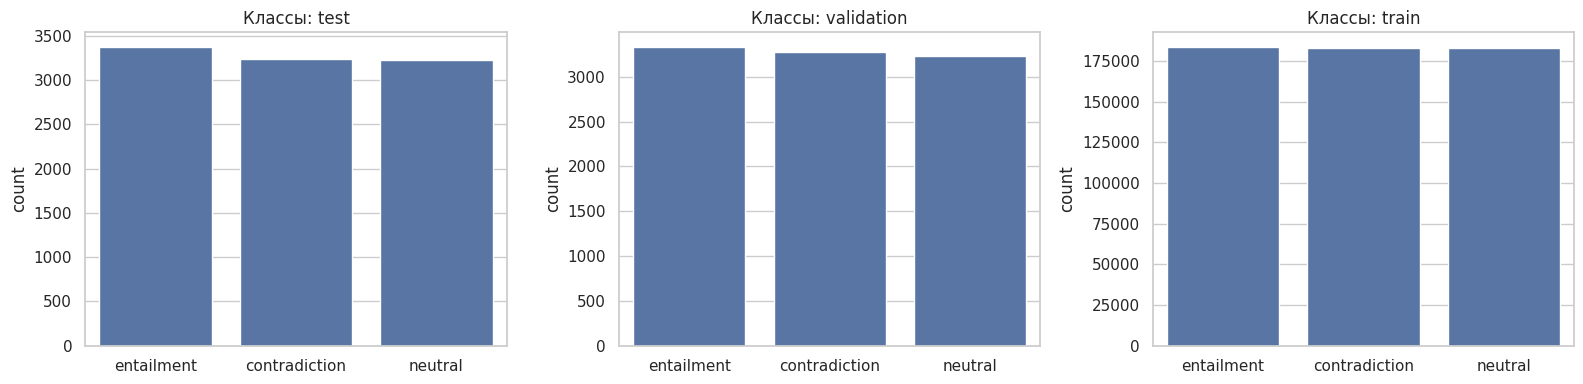

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, split in zip(axes, clean_ds.keys()):
    tmp = show_class_distribution(clean_ds[split], split)
    sns.barplot(data=tmp, x="label", y="count", ax=ax)
    ax.set_title(f"Классы: {split}")
    ax.set_xlabel("")
    ax.set_ylabel("count")
plt.tight_layout()
plt.show()


In [10]:
def stratified_subsample(ds: Dataset, n: int, seed: int = 42) -> Dataset:
    if n >= len(ds):
        return ds

    df = ds.to_pandas()[["premise", "hypothesis", "label"]]
    parts = []
    label_counts = df["label"].value_counts(normalize=True).sort_index()

    allocated = {}
    running_total = 0
    for label, frac in label_counts.items():
        k = int(round(frac * n))
        allocated[label] = k
        running_total += k

    diff = n - running_total
    labels_sorted = list(label_counts.index)
    idx = 0
    while diff != 0:
        label = labels_sorted[idx % len(labels_sorted)]
        if diff > 0:
            allocated[label] += 1
            diff -= 1
        else:
            if allocated[label] > 1:
                allocated[label] -= 1
                diff += 1
        idx += 1

    for label in labels_sorted:
        part = df[df["label"] == label].sample(
            n=min(allocated[label], (df["label"] == label).sum()),
            random_state=seed,
            replace=False,
        )
        parts.append(part)

    out = pd.concat(parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return Dataset.from_pandas(out, preserve_index=False)

if CFG.mode == "kaggle_safe":
    exp_ds = DatasetDict(
        train=stratified_subsample(clean_ds["train"], CFG.kaggle_train_size, seed=CFG.seed),
        validation=stratified_subsample(clean_ds["validation"], CFG.kaggle_val_size, seed=CFG.seed),
        test=stratified_subsample(clean_ds["test"], CFG.kaggle_test_size, seed=CFG.seed),
    )
else:
    exp_ds = clean_ds

exp_sizes = pd.DataFrame(
    [{"split": split, "size_used_in_experiment": len(exp_ds[split])} for split in exp_ds.keys()]
)
exp_sizes


,split,size_used_in_experiment
0,test,9824
1,validation,9842
2,train,549367


In [11]:
def add_basic_length_features(ds: Dataset) -> pd.DataFrame:
    df = ds.to_pandas()[["premise", "hypothesis", "label"]].copy()
    df["premise_words"] = df["premise"].str.split().str.len()
    df["hypothesis_words"] = df["hypothesis"].str.split().str.len()
    df["pair_words_sum"] = df["premise_words"] + df["hypothesis_words"]
    return df

eda_train = add_basic_length_features(exp_ds["train"])
eda_train.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T


,count,mean,std,min,50%,90%,95%,99%,max
label,549367.0,0.999583,0.816897,0.0,1.0,2.0,2.0,2.0,2.0
premise_words,549367.0,12.849376,5.656857,2.0,12.0,20.0,23.0,31.0,78.0
hypothesis_words,549367.0,7.415748,3.067807,1.0,7.0,11.0,13.0,18.0,56.0
pair_words_sum,549367.0,20.265123,6.952120,4.0,19.0,29.0,33.0,42.0,112.0


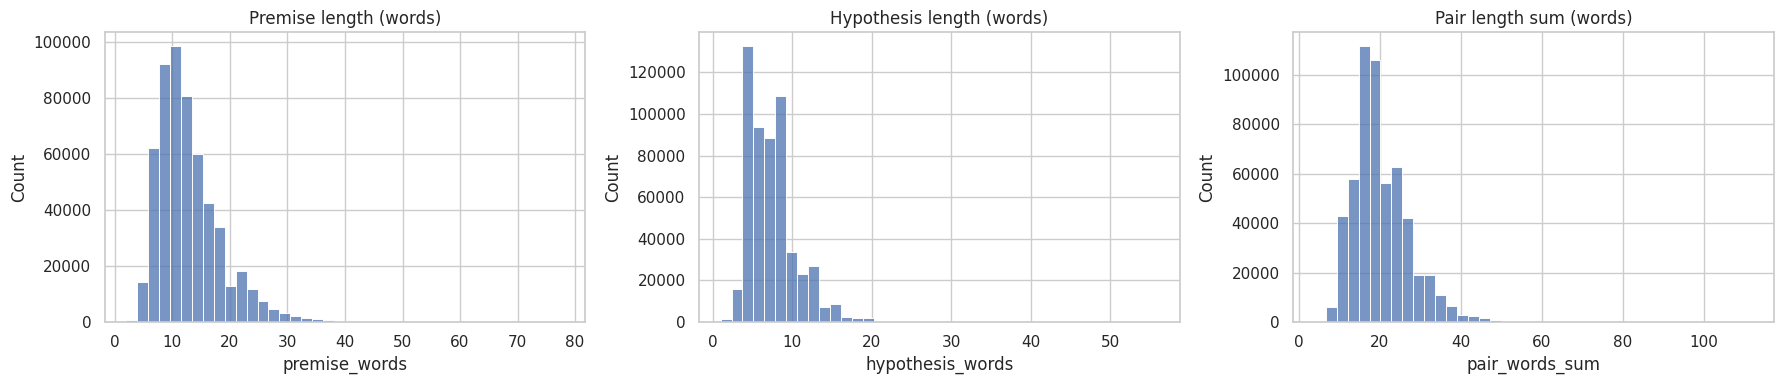

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(eda_train["premise_words"], bins=40, ax=axes[0])
axes[0].set_title("Premise length (words)")
sns.histplot(eda_train["hypothesis_words"], bins=40, ax=axes[1])
axes[1].set_title("Hypothesis length (words)")
sns.histplot(eda_train["pair_words_sum"], bins=40, ax=axes[2])
axes[2].set_title("Pair length sum (words)")
plt.tight_layout()
plt.show()


In [13]:
sample_preview = exp_ds["train"].select(range(3)).to_pandas()
sample_preview


,premise,hypothesis,label
0,A person on a horse jumps over a broken down airplane.,A person is training his horse for a competition.,1
1,A person on a horse jumps over a broken down airplane.,"A person is at a diner, ordering an omelette.",2
2,A person on a horse jumps over a broken down airplane.,"A person is outdoors, on a horse.",0


In [14]:
def tokenization_preview(ds: Dataset, n: int = 3):
    rows = []
    for ex in ds.select(range(n)):
        enc = tokenizer(
            ex["premise"],
            ex["hypothesis"],
            truncation=True,
            max_length=CFG.max_len,
            return_attention_mask=True,
        )
        tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"])
        rows.append(
            {
                "label": label_id2name[ex["label"]],
                "premise": ex["premise"],
                "hypothesis": ex["hypothesis"],
                "token_count_after_trunc": len(enc["input_ids"]),
                "tokens_preview": tokens[:40],
            }
        )
    return pd.DataFrame(rows)

tokenization_preview(exp_ds["train"], n=3)


,label,premise,hypothesis,token_count_after_trunc,tokens_preview
0,neutral,A person on a horse jumps over a broken down airplane.,A person is training his horse for a competition.,25,"[[CLS], a, person, on, a, horse, jumps, over, a, broken, down, airplane, ., [SEP], a, person, is, training, his, horse, for, a, competition, ., [SEP]]"
1,contradiction,A person on a horse jumps over a broken down airplane.,"A person is at a diner, ordering an omelette.",28,"[[CLS], a, person, on, a, horse, jumps, over, a, broken, down, airplane, ., [SEP], a, person, is, at, a, diner, ,, ordering, an, om, ##ele, ##tte, ., [SEP]]"
2,entailment,A person on a horse jumps over a broken down airplane.,"A person is outdoors, on a horse.",24,"[[CLS], a, person, on, a, horse, jumps, over, a, broken, down, airplane, ., [SEP], a, person, is, outdoors, ,, on, a, horse, ., [SEP]]"


In [15]:
def estimate_truncation_share(ds: Dataset, sample_size: Optional[int] = None, seed: int = 42):
    if sample_size is not None and sample_size < len(ds):
        ds = stratified_subsample(ds, sample_size, seed=seed)

    lengths = []
    for ex in ds:
        ids = tokenizer(
            ex["premise"],
            ex["hypothesis"],
            truncation=False,
            add_special_tokens=True,
        )["input_ids"]
        lengths.append(len(ids))

    lengths = np.array(lengths)
    stats = {
        "n_examples": int(len(lengths)),
        "max_len_setting": CFG.max_len,
        "mean_tokens": round(float(lengths.mean()), 2),
        "p90_tokens": int(np.percentile(lengths, 90)),
        "p95_tokens": int(np.percentile(lengths, 95)),
        "p99_tokens": int(np.percentile(lengths, 99)),
        "max_tokens": int(lengths.max()),
        "truncated_share_%": round(float((lengths > CFG.max_len).mean() * 100), 2),
    }
    return stats, lengths

trunc_rows = []
length_store = {}
for split in exp_ds.keys():
    sample_size = None if len(exp_ds[split]) <= CFG.trunc_stats_sample_size else CFG.trunc_stats_sample_size
    stats, lengths = estimate_truncation_share(exp_ds[split], sample_size=sample_size, seed=CFG.seed)
    stats["split"] = split
    trunc_rows.append(stats)
    length_store[split] = lengths

trunc_df = pd.DataFrame(trunc_rows)[
    ["split", "n_examples", "max_len_setting", "mean_tokens", "p90_tokens", "p95_tokens", "p99_tokens", "max_tokens", "truncated_share_%"]
]
trunc_df


,split,n_examples,max_len_setting,mean_tokens,p90_tokens,p95_tokens,p99_tokens,max_tokens,truncated_share_%
0,test,9824,64,27.41,38,42,52,76,0.06
1,validation,9842,64,27.45,38,42,53,113,0.34
2,train,20000,64,26.19,36,41,50,95,0.15


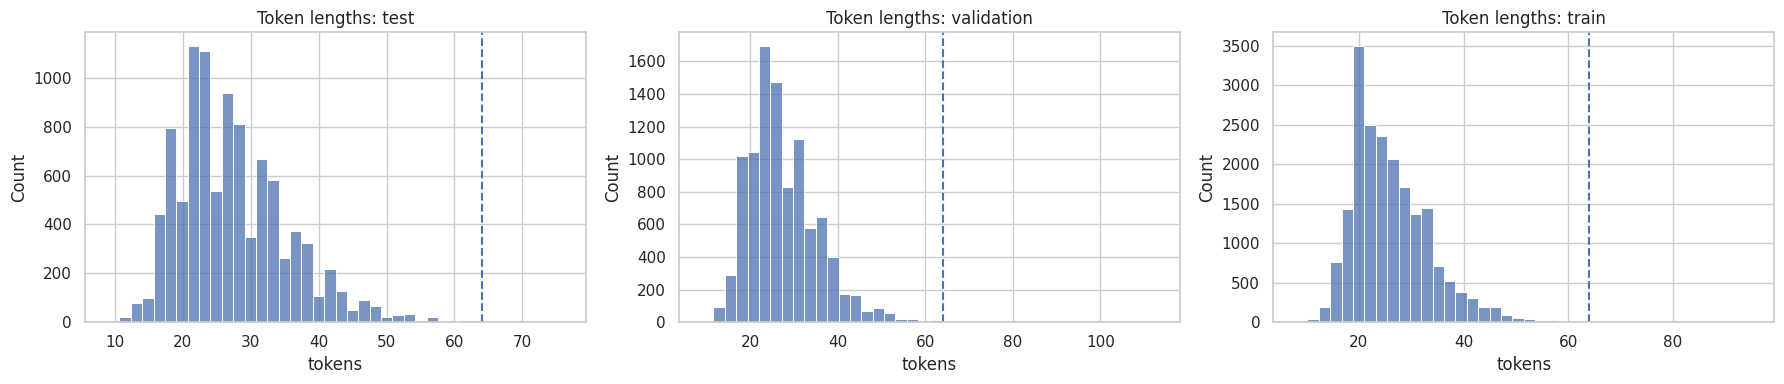

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, split in zip(axes, exp_ds.keys()):
    sns.histplot(length_store[split], bins=40, ax=ax)
    ax.axvline(CFG.max_len, linestyle="--")
    ax.set_title(f"Token lengths: {split}")
    ax.set_xlabel("tokens")
plt.tight_layout()
plt.show()


In [17]:
def tokenize_batch(batch):
    return tokenizer(
        batch["premise"],
        batch["hypothesis"],
        truncation=True,
        max_length=CFG.max_len,
        return_attention_mask=True,
        return_token_type_ids=True,
    )

tokenized_ds = DatasetDict()
for split in exp_ds.keys():
    tokenized_ds[split] = exp_ds[split].map(
        tokenize_batch,
        batched=True,
        remove_columns=["premise", "hypothesis"]
    )

tokenized_ds = tokenized_ds.rename_column("label", "labels")
tokenized_ds.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "token_type_ids", "labels"]
)

collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding="longest",
    return_tensors="pt"
)

def make_loaders(tokenized_ds, seed):
    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        tokenized_ds["train"],
        batch_size=CFG.batch_size,
        shuffle=True,
        num_workers=CFG.num_workers,
        collate_fn=collator,
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=seed_worker,
        generator=g,
    )
    val_loader = DataLoader(
        tokenized_ds["validation"],
        batch_size=CFG.batch_size,
        shuffle=False,
        num_workers=CFG.num_workers,
        collate_fn=collator,
        pin_memory=torch.cuda.is_available(),
    )
    test_loader = DataLoader(
        tokenized_ds["test"],
        batch_size=CFG.batch_size,
        shuffle=False,
        num_workers=CFG.num_workers,
        collate_fn=collator,
        pin_memory=torch.cuda.is_available(),
    )
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(tokenized_ds, CFG.seed)

len(train_loader), len(val_loader), len(test_loader)

Map:   0%|          | 0/9824 [00:00<?, ? examples/s]

Map:   0%|          | 0/9842 [00:00<?, ? examples/s]

Map:   0%|          | 0/549367 [00:00<?, ? examples/s]

(17168, 308, 307)

In [18]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, max_len: int, d_model: int):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0), persistent=False)

    def forward(self, x):
        return self.pe[:, : x.size(1)]

class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: float):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.dropout1 = nn.Dropout(dropout)

        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask=None, need_weights=False):
        y = self.ln1(x)
        attn_out, attn_weights = self.attn(
            y,
            y,
            y,
            key_padding_mask=key_padding_mask,
            need_weights=need_weights,
            average_attn_weights=False,
        )
        x = x + self.dropout1(attn_out)

        y = self.ln2(x)
        x = x + self.dropout2(self.ffn(y))
        return x, attn_weights

class CompactTransformerNLI(nn.Module):
    def __init__(self, cfg: CompactConfig):
        super().__init__()
        self.cfg = cfg
        self.token_embeddings = nn.Embedding(cfg.vocab_size, cfg.d_model, padding_idx=cfg.pad_token_id)
        self.token_type_embeddings = nn.Embedding(cfg.type_vocab_size, cfg.d_model)

        if cfg.pos_encoding == "learnable":
            self.position_embeddings = nn.Embedding(cfg.max_len, cfg.d_model)
            self.pos_encoder = None
        elif cfg.pos_encoding == "sinusoidal":
            self.position_embeddings = None
            self.pos_encoder = SinusoidalPositionalEncoding(cfg.max_len, cfg.d_model)
        else:
            raise ValueError(f"Unknown pos_encoding: {cfg.pos_encoding}")

        self.emb_dropout = nn.Dropout(cfg.dropout)
        self.layers = nn.ModuleList(
            [
                TransformerEncoderBlock(
                    d_model=cfg.d_model,
                    num_heads=cfg.num_heads,
                    d_ff=cfg.d_ff,
                    dropout=cfg.dropout,
                )
                for _ in range(cfg.num_layers)
            ]
        )
        self.final_ln = nn.LayerNorm(cfg.d_model)
        self.classifier = nn.Sequential(
            nn.Linear(cfg.d_model, cfg.d_model),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.d_model, cfg.num_labels),
        )

    def get_embeddings(self, input_ids, token_type_ids):
        bsz, seq_len = input_ids.shape
        x = self.token_embeddings(input_ids) + self.token_type_embeddings(token_type_ids)

        if self.position_embeddings is not None:
            pos_ids = torch.arange(seq_len, device=input_ids.device).unsqueeze(0).expand(bsz, -1)
            x = x + self.position_embeddings(pos_ids)
        else:
            x = x + self.pos_encoder(x)

        return self.emb_dropout(x)

    def pool_sequence(self, x, attention_mask):
        if self.cfg.pooling == "cls":
            return x[:, 0]
        if self.cfg.pooling == "mean":
            mask = attention_mask.unsqueeze(-1).float()
            return (x * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1e-9)
        if self.cfg.pooling == "max":
            mask = attention_mask.unsqueeze(-1).bool()
            x_masked = x.masked_fill(~mask, float("-inf"))
            return x_masked.max(dim=1).values
        raise ValueError(f"Unknown pooling: {self.cfg.pooling}")

    def forward(self, input_ids, attention_mask, token_type_ids, return_attentions=False):
        x = self.get_embeddings(input_ids, token_type_ids)
        key_padding_mask = attention_mask == 0

        attentions = []
        for layer in self.layers:
            x, attn = layer(x, key_padding_mask=key_padding_mask, need_weights=return_attentions)
            if return_attentions:
                attentions.append(attn)

        x = self.final_ln(x)
        pooled = self.pool_sequence(x, attention_mask)
        logits = self.classifier(pooled)
        out = {"logits": logits}
        if return_attentions:
            out["attentions"] = attentions
        return out


In [19]:
def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def build_compact_model(
    pooling: str = "cls",
    pos_encoding: str = "learnable",
    num_layers: int = 4,
    d_model: int = 256,
    num_heads: int = 4,
    d_ff: int = 512,
    dropout: float = 0.1,
):
    cfg = CompactConfig(
        vocab_size=tokenizer.vocab_size,
        max_len=CFG.max_len,
        num_labels=3,
        pad_token_id=tokenizer.pad_token_id,
        d_model=d_model,
        num_heads=num_heads,
        num_layers=num_layers,
        d_ff=d_ff,
        dropout=dropout,
        pooling=pooling,
        pos_encoding=pos_encoding,
    )
    model = CompactTransformerNLI(cfg)
    return model, cfg

compact_model, compact_cfg = build_compact_model()
compact_params = count_trainable_params(compact_model)
compact_params


10006019

In [20]:
def build_bert_model():
    model = AutoModelForSequenceClassification.from_pretrained(
        CFG.model_name,
        num_labels=3,
    )
    return model

bert_model = build_bert_model()
bert_params = count_trainable_params(bert_model)
pd.DataFrame(
    [
        {"model": "CompactTransformer", "trainable_params": compact_params},
        {"model": "BERT", "trainable_params": bert_params},
    ]
)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,model,trainable_params
0,CompactTransformer,10006019
1,BERT,109484547


In [21]:
def compute_metrics(y_true, y_pred) -> Dict[str, float]:
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1, 2], zero_division=0
    )
    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted")),
    }
    per_class = pd.DataFrame(
        {
            "label_id": [0, 1, 2],
            "label_name": [label_id2name[i] for i in [0, 1, 2]],
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "support": support,
        }
    )
    return metrics, per_class

def multiclass_nll(y_true: np.ndarray, probs: np.ndarray) -> float:
    idx = np.arange(len(y_true))
    p = np.clip(probs[idx, y_true], 1e-12, 1.0)
    return float(-np.mean(np.log(p)))

def multiclass_brier_score(y_true: np.ndarray, probs: np.ndarray) -> float:
    one_hot = np.eye(probs.shape[1])[y_true]
    return float(np.mean(np.sum((probs - one_hot) ** 2, axis=1)))

def expected_calibration_error(y_true: np.ndarray, probs: np.ndarray, n_bins: int = 15):
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    correct = (pred == y_true).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    rows = []
    ece = 0.0

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i == n_bins - 1:
            mask = (conf >= lo) & (conf <= hi)
        else:
            mask = (conf >= lo) & (conf < hi)

        n = int(mask.sum())
        if n == 0:
            continue

        bin_acc = float(correct[mask].mean())
        bin_conf = float(conf[mask].mean())
        share = float(mask.mean())

        rows.append(
            {
                "bin_left": round(float(lo), 4),
                "bin_right": round(float(hi), 4),
                "count": n,
                "share": share,
                "accuracy": bin_acc,
                "confidence": bin_conf,
                "gap": abs(bin_acc - bin_conf),
            }
        )
        ece += abs(bin_acc - bin_conf) * share

    return float(ece), pd.DataFrame(rows)

def collect_calibration_metrics(y_true: np.ndarray, probs: np.ndarray, n_bins: int = 15):
    ece, rel_df = expected_calibration_error(y_true, probs, n_bins=n_bins)
    return {
        "nll": multiclass_nll(y_true, probs),
        "brier": multiclass_brier_score(y_true, probs),
        "ece": ece,
        "reliability_df": rel_df,
    }

def plot_reliability_diagram(rel_df: pd.DataFrame, title: str):
    if rel_df.empty:
        print(f"{title}: no populated bins.")
        return

    plt.figure(figsize=(5.5, 5.0))
    plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)
    plt.plot(rel_df["confidence"], rel_df["accuracy"], marker="o")
    plt.title(title)
    plt.xlabel("Mean confidence")
    plt.ylabel("Empirical accuracy")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

def fit_temperature(val_logits: np.ndarray, val_labels: np.ndarray, max_iter: int = 50) -> float:
    logits_t = torch.tensor(val_logits, dtype=torch.float32, device=device)
    labels_t = torch.tensor(val_labels, dtype=torch.long, device=device)
    temperature = nn.Parameter(torch.ones(1, device=device))
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.LBFGS([temperature], lr=0.01, max_iter=max_iter)

    def closure():
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(logits_t / temperature.clamp_min(1e-3), labels_t)
        loss.backward()
        return loss

    optimizer.step(closure)
    return float(temperature.detach().cpu().item())

def softmax_np(logits: np.ndarray) -> np.ndarray:
    logits = logits - logits.max(axis=1, keepdims=True)
    exps = np.exp(logits)
    return exps / exps.sum(axis=1, keepdims=True)

def apply_temperature(logits: np.ndarray, temperature: float) -> np.ndarray:
    return softmax_np(logits / max(float(temperature), 1e-6))

def summarize_probs(y_true: np.ndarray, probs: np.ndarray, *, prefix: str, n_bins: int = 15):
    metrics = collect_calibration_metrics(y_true, probs, n_bins=n_bins)
    return {
        f"{prefix}_nll": metrics["nll"],
        f"{prefix}_brier": metrics["brier"],
        f"{prefix}_ece": metrics["ece"],
        f"{prefix}_reliability_df": metrics["reliability_df"],
    }

def move_batch_to_device(batch, device):
    return {k: v.to(device) for k, v in batch.items()}

@torch.no_grad()
def evaluate_model(model, loader, model_type: str = "compact", loss_fn=None):
    model.eval()
    all_labels, all_preds, all_probs, all_logits = [], [], [], []
    losses = []

    for batch in loader:
        batch = move_batch_to_device(batch, device)
        labels = batch["labels"]

        if model_type == "bert":
            outputs = model(**batch)
            logits = outputs.logits
            loss = outputs.loss
        else:
            outputs = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                token_type_ids=batch["token_type_ids"],
            )
            logits = outputs["logits"]
            loss = loss_fn(logits, labels)

        probs = torch.softmax(logits, dim=-1)
        preds = probs.argmax(dim=-1)

        losses.append(loss.item())
        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_probs.extend(probs.detach().cpu().numpy().tolist())
        all_logits.extend(logits.detach().cpu().numpy().tolist())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    probs = np.array(all_probs)
    logits = np.array(all_logits)

    metrics, per_class = compute_metrics(y_true, y_pred)
    metrics["loss"] = float(np.mean(losses))
    metrics.update(
        {
            "nll": multiclass_nll(y_true, probs),
            "brier": multiclass_brier_score(y_true, probs),
            "ece": expected_calibration_error(y_true, probs, n_bins=CFG.calibration_bins)[0],
        }
    )
    return metrics, per_class, y_true, y_pred, probs, logits

def save_json(obj, path: Path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def plot_history(history: List[Dict], title: str):
    hist_df = pd.DataFrame(history)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.lineplot(data=hist_df, x="epoch", y="train_loss", marker="o", ax=axes[0], label="train_loss")
    sns.lineplot(data=hist_df, x="epoch", y="val_loss", marker="o", ax=axes[0], label="val_loss")
    axes[0].set_title(f"{title}: loss")

    sns.lineplot(data=hist_df, x="epoch", y="val_accuracy", marker="o", ax=axes[1], label="val_accuracy")
    sns.lineplot(data=hist_df, x="epoch", y="val_macro_f1", marker="o", ax=axes[1], label="val_macro_f1")
    axes[1].set_title(f"{title}: validation metrics")
    plt.tight_layout()
    plt.show()


In [22]:
def train_model(
    model,
    train_loader,
    val_loader,
    *,
    model_name: str,
    model_type: str,
    epochs: int,
    lr: float,
    weight_decay: float,
    warmup_ratio: float,
    early_stopping_patience: int,
):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    total_steps = epochs * len(train_loader)
    warmup_steps = int(total_steps * warmup_ratio)
    scheduler = get_linear_schedule_with_warmup(
        optimizer=optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)
    loss_fn = nn.CrossEntropyLoss()

    best_val_macro_f1 = -1.0
    best_epoch = -1
    best_path = CKPT_DIR / f"{model_name}_seed{CFG.seed}.pt"
    history = []
    patience_counter = 0
    overall_start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = []
        epoch_start = time.perf_counter()

        for batch in train_loader:
            batch = move_batch_to_device(batch, device)
            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=amp_enabled):
                if model_type == "bert":
                    outputs = model(**batch)
                    loss = outputs.loss
                else:
                    outputs = model(
                        input_ids=batch["input_ids"],
                        attention_mask=batch["attention_mask"],
                        token_type_ids=batch["token_type_ids"],
                    )
                    loss = loss_fn(outputs["logits"], batch["labels"])

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            running_loss.append(loss.item())

        train_loss = float(np.mean(running_loss))
        val_metrics, _, _, _, _, _ = evaluate_model(
            model,
            val_loader,
            model_type=model_type,
            loss_fn=loss_fn,
        )
        epoch_time = time.perf_counter() - epoch_start

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
            "val_ece": val_metrics["ece"],
            "epoch_time_sec": epoch_time,
            "lr_last": scheduler.get_last_lr()[0],
        }
        history.append(row)

        print(
            f"[{model_name}] epoch={epoch:02d} "
            f"train_loss={train_loss:.4f} "
            f"val_loss={val_metrics['loss']:.4f} "
            f"val_acc={val_metrics['accuracy']:.4f} "
            f"val_macro_f1={val_metrics['macro_f1']:.4f} "
            f"val_ece={val_metrics['ece']:.4f} "
            f"time={epoch_time:.1f}s"
        )

        if val_metrics["macro_f1"] > best_val_macro_f1:
            best_val_macro_f1 = val_metrics["macro_f1"]
            best_epoch = epoch
            torch.save({"model_state_dict": model.state_dict(), "best_epoch": epoch}, best_path)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                print(f"Early stopping: no validation macro-F1 improvement for {early_stopping_patience} epochs.")
                break

    total_train_time = time.perf_counter() - overall_start

    checkpoint = torch.load(best_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    return model, history, total_train_time, str(best_path), best_epoch


In [23]:
@torch.no_grad()
def benchmark_inference(model, loader, model_type: str, warmup_batches: int = 3, measure_batches: int = 10):
    model.eval()
    batches = []

    for i, batch in enumerate(loader):
        if i >= warmup_batches + measure_batches:
            break
        batch = move_batch_to_device(batch, device)
        if i < warmup_batches:
            if model_type == "bert":
                _ = model(**batch)
            else:
                _ = model(
                    input_ids=batch["input_ids"],
                    attention_mask=batch["attention_mask"],
                    token_type_ids=batch["token_type_ids"],
                )
            continue

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        start = time.perf_counter()
        if model_type == "bert":
            _ = model(**batch)
        else:
            _ = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                token_type_ids=batch["token_type_ids"],
            )
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        elapsed = time.perf_counter() - start
        batches.append((elapsed, batch["input_ids"].size(0)))

    total_time = sum(x[0] for x in batches)
    total_items = sum(x[1] for x in batches)
    batch_times = [x[0] for x in batches]

    return {
        "measured_batches": len(batches),
        "total_items": total_items,
        "avg_batch_time_sec": total_time / max(len(batches), 1),
        "p50_batch_time_sec": float(np.percentile(batch_times, 50)) if batch_times else float("nan"),
        "p95_batch_time_sec": float(np.percentile(batch_times, 95)) if batch_times else float("nan"),
        "items_per_sec": total_items / max(total_time, 1e-9),
    }

def plot_confusion(y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    cm_df = pd.DataFrame(
        cm,
        index=[label_id2name[i] for i in [0, 1, 2]],
        columns=[label_id2name[i] for i in [0, 1, 2]],
    )
    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.ylabel("True")
    plt.xlabel("Pred")
    plt.tight_layout()
    plt.show()
    return cm_df

def compression_ratio(small_params: int, large_params: int) -> float:
    return float(large_params / max(small_params, 1))

def safe_div(a: float, b: float) -> float:
    return float(a / b) if b else float("nan")


/tmp/ipykernel_26/4225700641.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)
/tmp/ipykernel_26/4225700641.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


[compact_base] epoch=01 train_loss=0.9277 val_loss=0.8050 val_acc=0.6407 val_macro_f1=0.6403 val_ece=0.0146 time=353.7s


/tmp/ipykernel_26/4225700641.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


[compact_base] epoch=02 train_loss=0.7868 val_loss=0.7043 val_acc=0.7065 val_macro_f1=0.7016 val_ece=0.0329 time=349.1s


/tmp/ipykernel_26/4225700641.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


...

[compact_base] epoch=06 train_loss=0.5655 val_loss=0.5267 val_acc=0.7902 val_macro_f1=0.7883 val_ece=0.0339 time=350.5s


/tmp/ipykernel_26/4225700641.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


[compact_base] epoch=07 train_loss=0.5444 val_loss=0.5091 val_acc=0.8004 val_macro_f1=0.7994 val_ece=0.0280 time=349.4s


/tmp/ipykernel_26/4225700641.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


[compact_base] epoch=08 train_loss=0.5293 val_loss=0.5104 val_acc=0.8012 val_macro_f1=0.8001 val_ece=0.0356 time=350.3s


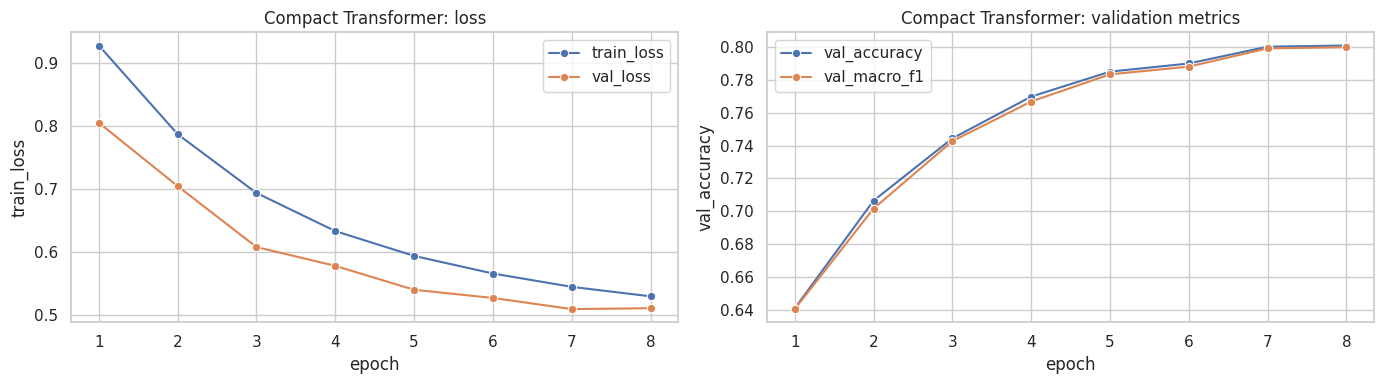

In [24]:
compact_model, compact_cfg = build_compact_model()

compact_model, compact_history, compact_train_time, compact_ckpt, compact_best_epoch = train_model(
    compact_model,
    train_loader,
    val_loader,
    model_name="compact_base",
    model_type="compact",
    epochs=CFG.epochs_custom,
    lr=CFG.lr_custom,
    weight_decay=CFG.weight_decay,
    warmup_ratio=CFG.warmup_ratio,
    early_stopping_patience=CFG.early_stopping_patience,
)

plot_history(compact_history, "Compact Transformer")


In [25]:
compact_loss_fn = nn.CrossEntropyLoss()
compact_val_metrics, compact_val_per_class, compact_val_y_true, compact_val_y_pred, compact_val_probs, compact_val_logits = evaluate_model(
    compact_model, val_loader, model_type="compact", loss_fn=compact_loss_fn
)
compact_test_metrics, compact_test_per_class, compact_y_true, compact_y_pred, compact_probs, compact_logits = evaluate_model(
    compact_model, test_loader, model_type="compact", loss_fn=compact_loss_fn
)
compact_infer_stats = benchmark_inference(compact_model, test_loader, model_type="compact")

compact_result = {
    "model": "CompactTransformer",
    "checkpoint": compact_ckpt,
    "best_epoch": compact_best_epoch,
    "train_time_sec": compact_train_time,
    "trainable_params": count_trainable_params(compact_model),
    "val_accuracy": compact_val_metrics["accuracy"],
    "val_macro_f1": compact_val_metrics["macro_f1"],
    "val_weighted_f1": compact_val_metrics["weighted_f1"],
    "val_ece": compact_val_metrics["ece"],
    "test_accuracy": compact_test_metrics["accuracy"],
    "test_macro_f1": compact_test_metrics["macro_f1"],
    "test_weighted_f1": compact_test_metrics["weighted_f1"],
    "test_loss": compact_test_metrics["loss"],
    "test_nll": compact_test_metrics["nll"],
    "test_brier": compact_test_metrics["brier"],
    "test_ece": compact_test_metrics["ece"],
    "items_per_sec": compact_infer_stats["items_per_sec"],
    "avg_batch_time_sec": compact_infer_stats["avg_batch_time_sec"],
    "p95_batch_time_sec": compact_infer_stats["p95_batch_time_sec"],
}
save_json(compact_result, OUTPUT_DIR / "compact_result.json")
pd.DataFrame([compact_result]).round(4)


,model,checkpoint,best_epoch,train_time_sec,trainable_params,val_accuracy,val_macro_f1,val_weighted_f1,val_ece,test_accuracy,test_macro_f1,test_weighted_f1,test_loss,test_nll,test_brier,test_ece,items_per_sec,avg_batch_time_sec,p95_batch_time_sec
0,CompactTransformer,outputs_nli/checkpoints/compact_base_seed42.pt,8,2791.1932,10006019,0.8012,0.8001,0.8005,0.0356,0.7929,0.7919,0.7926,0.5129,0.5129,0.2909,0.0427,6030.9955,0.0053,0.0062


In [26]:
compact_val_per_class


,label_id,label_name,precision,recall,f1,support
0,0,entailment,0.819574,0.867828,0.843011,3329
1,1,neutral,0.761450,0.740031,0.750588,3235
2,2,contradiction,0.820044,0.793777,0.806697,3278


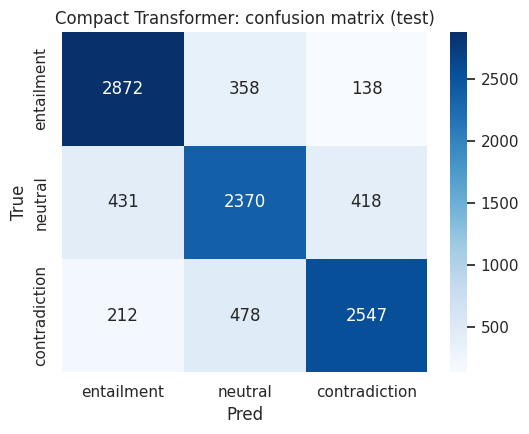

,entailment,neutral,contradiction
entailment,2872,358,138
neutral,431,2370,418
contradiction,212,478,2547


In [27]:
plot_confusion(compact_y_true, compact_y_pred, "Compact Transformer: confusion matrix (test)")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_26/4225700641.py:23: F

[bert_base] epoch=01 train_loss=0.4075 val_loss=0.2727 val_acc=0.9004 val_macro_f1=0.9006 val_ece=0.0138 time=1930.4s


/tmp/ipykernel_26/4225700641.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


[bert_base] epoch=02 train_loss=0.2639 val_loss=0.2709 val_acc=0.9056 val_macro_f1=0.9050 val_ece=0.0245 time=1932.5s


/tmp/ipykernel_26/4225700641.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


[bert_base] epoch=03 train_loss=0.1941 val_loss=0.2902 val_acc=0.9114 val_macro_f1=0.9112 val_ece=0.0412 time=1931.4s


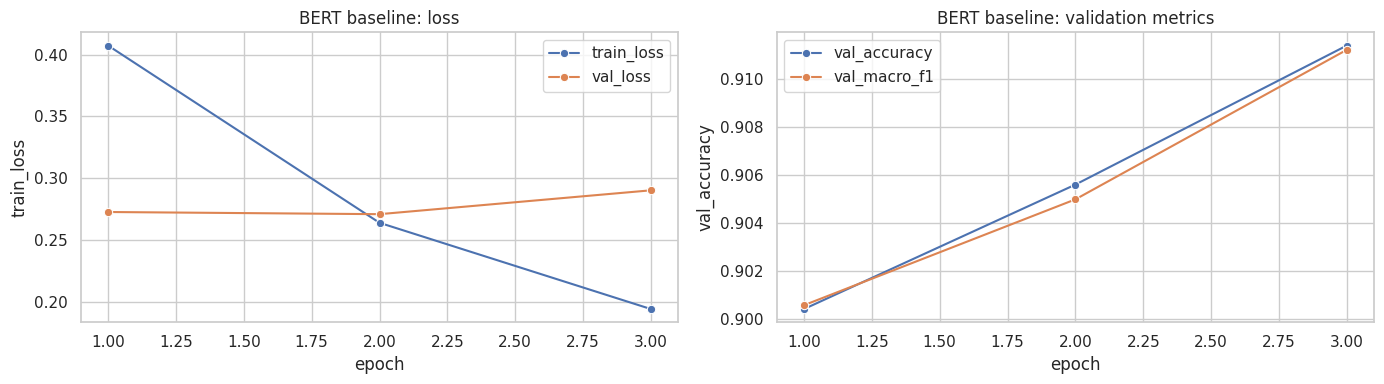

In [28]:
bert_model = build_bert_model()

bert_model, bert_history, bert_train_time, bert_ckpt, bert_best_epoch = train_model(
    bert_model,
    train_loader,
    val_loader,
    model_name="bert_base",
    model_type="bert",
    epochs=CFG.epochs_bert,
    lr=CFG.lr_bert,
    weight_decay=CFG.weight_decay,
    warmup_ratio=CFG.warmup_ratio,
    early_stopping_patience=CFG.early_stopping_patience,
)

plot_history(bert_history, "BERT baseline")


In [29]:
bert_val_metrics, bert_val_per_class, bert_val_y_true, bert_val_y_pred, bert_val_probs, bert_val_logits = evaluate_model(
    bert_model, val_loader, model_type="bert"
)
bert_test_metrics, bert_test_per_class, bert_y_true, bert_y_pred, bert_probs, bert_logits = evaluate_model(
    bert_model, test_loader, model_type="bert"
)
bert_infer_stats = benchmark_inference(bert_model, test_loader, model_type="bert")

bert_result = {
    "model": "BERT",
    "checkpoint": bert_ckpt,
    "best_epoch": bert_best_epoch,
    "train_time_sec": bert_train_time,
    "trainable_params": count_trainable_params(bert_model),
    "val_accuracy": bert_val_metrics["accuracy"],
    "val_macro_f1": bert_val_metrics["macro_f1"],
    "val_weighted_f1": bert_val_metrics["weighted_f1"],
    "val_ece": bert_val_metrics["ece"],
    "test_accuracy": bert_test_metrics["accuracy"],
    "test_macro_f1": bert_test_metrics["macro_f1"],
    "test_weighted_f1": bert_test_metrics["weighted_f1"],
    "test_loss": bert_test_metrics["loss"],
    "test_nll": bert_test_metrics["nll"],
    "test_brier": bert_test_metrics["brier"],
    "test_ece": bert_test_metrics["ece"],
    "items_per_sec": bert_infer_stats["items_per_sec"],
    "avg_batch_time_sec": bert_infer_stats["avg_batch_time_sec"],
    "p95_batch_time_sec": bert_infer_stats["p95_batch_time_sec"],
}
save_json(bert_result, OUTPUT_DIR / "bert_result.json")
pd.DataFrame([bert_result]).round(4)


,model,checkpoint,best_epoch,train_time_sec,trainable_params,val_accuracy,val_macro_f1,val_weighted_f1,val_ece,test_accuracy,test_macro_f1,test_weighted_f1,test_loss,test_nll,test_brier,test_ece,items_per_sec,avg_batch_time_sec,p95_batch_time_sec
0,BERT,outputs_nli/checkpoints/bert_base_seed42.pt,3,5796.8994,109484547,0.9114,0.9112,0.9114,0.0412,0.9073,0.907,0.9072,0.2986,0.2986,0.1476,0.0443,328.3927,0.0974,0.1141


In [30]:
bert_val_per_class


,label_id,label_name,precision,recall,f1,support
0,0,entailment,0.928375,0.914989,0.921634,3329
1,1,neutral,0.876961,0.881298,0.879124,3235
2,2,contradiction,0.928399,0.937462,0.932908,3278


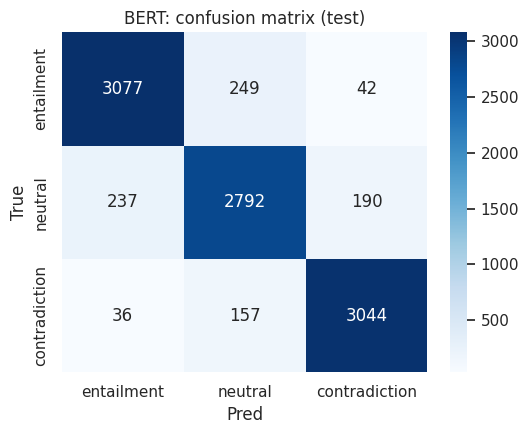

,entailment,neutral,contradiction
entailment,3077,249,42
neutral,237,2792,190
contradiction,36,157,3044


In [31]:
plot_confusion(bert_y_true, bert_y_pred, "BERT: confusion matrix (test)")


In [32]:
compare_df = pd.DataFrame([compact_result, bert_result]).copy()
compare_df["params_millions"] = (compare_df["trainable_params"] / 1_000_000).round(2)
compare_df["train_time_min"] = (compare_df["train_time_sec"] / 60).round(2)
compare_df["speed_items_per_sec"] = compare_df["items_per_sec"].round(2)

compare_df = compare_df[
    [
        "model",
        "params_millions",
        "best_epoch",
        "val_accuracy",
        "val_macro_f1",
        "val_ece",
        "test_accuracy",
        "test_macro_f1",
        "test_weighted_f1",
        "test_nll",
        "test_brier",
        "test_ece",
        "train_time_min",
        "speed_items_per_sec",
        "avg_batch_time_sec",
        "p95_batch_time_sec",
        "checkpoint",
    ]
].sort_values("test_macro_f1", ascending=False)

compact_params = compact_result["trainable_params"]
bert_params = bert_result["trainable_params"]

relative_df = pd.DataFrame(
    [
        {
            "comparison": "BERT / Compact size ratio",
            "value": round(compression_ratio(compact_params, bert_params), 2),
        },
        {
            "comparison": "Compact / BERT train time ratio",
            "value": round(safe_div(compact_result["train_time_sec"], bert_result["train_time_sec"]), 3),
        },
        {
            "comparison": "Compact / BERT throughput ratio",
            "value": round(safe_div(compact_result["items_per_sec"], bert_result["items_per_sec"]), 3),
        },
        {
            "comparison": "Macro-F1 gap (BERT - Compact)",
            "value": round(bert_result["test_macro_f1"] - compact_result["test_macro_f1"], 4),
        },
    ]
)

compare_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
relative_df.to_csv(OUTPUT_DIR / "relative_tradeoff_summary.csv", index=False)

display(compare_df.round(4))
display(relative_df)


,model,params_millions,best_epoch,val_accuracy,val_macro_f1,val_ece,test_accuracy,test_macro_f1,test_weighted_f1,test_nll,test_brier,test_ece,train_time_min,speed_items_per_sec,avg_batch_time_sec,p95_batch_time_sec,checkpoint
1,BERT,109.48,3,0.9114,0.9112,0.0412,0.9073,0.9070,0.9072,0.2986,0.1476,0.0443,96.61,328.39,0.0974,0.1141,outputs_nli/checkpoints/bert_base_seed42.pt
0,CompactTransformer,10.01,8,0.8012,0.8001,0.0356,0.7929,0.7919,0.7926,0.5129,0.2909,0.0427,46.52,6031.00,0.0053,0.0062,outputs_nli/checkpoints/compact_base_seed42.pt


,comparison,value
0,BERT / Compact size ratio,10.9400
1,Compact / BERT train time ratio,0.4810
2,Compact / BERT throughput ratio,18.3650
3,Macro-F1 gap (BERT - Compact),0.1151


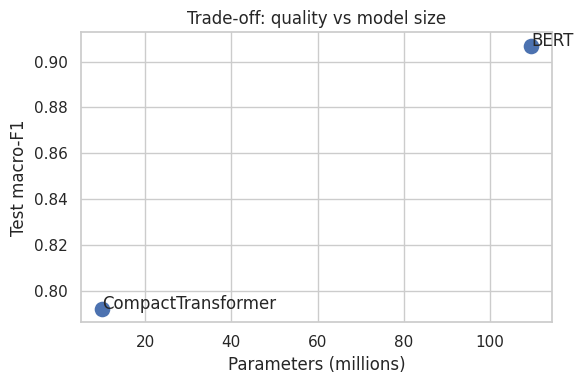

In [33]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=compare_df, x="params_millions", y="test_macro_f1", s=150)
for _, row in compare_df.iterrows():
    plt.text(row["params_millions"] + 0.1, row["test_macro_f1"], row["model"])
plt.title("Trade-off: quality vs model size")
plt.xlabel("Parameters (millions)")
plt.ylabel("Test macro-F1")
plt.tight_layout()
plt.show()



## Calibration и confidence analysis

Одна accuracy здесь недостаточна. Для практической интерпретации важно понимать, насколько хорошо вероятности модели соотносятся с реальной частотой правильных ответов.

В этом блоке считаются:

- **NLL**
- **Brier score**
- **ECE** (Expected Calibration Error)
- reliability diagram

Дополнительно, если `CFG.run_temperature_scaling = True`, применяется **post-hoc temperature scaling** по validation logits и затем оценивается эффект на test set.  
Это полезно, потому что позволяет показать не только проблему калибровки, но и дешёвый способ её частично исправить без переобучения модели.


In [34]:

compact_cal_raw = collect_calibration_metrics(compact_y_true, compact_probs, n_bins=CFG.calibration_bins)
bert_cal_raw = collect_calibration_metrics(bert_y_true, bert_probs, n_bins=CFG.calibration_bins)

calibration_rows = [
    {
        "model": "CompactTransformer",
        "stage": "raw",
        "nll": compact_cal_raw["nll"],
        "brier": compact_cal_raw["brier"],
        "ece": compact_cal_raw["ece"],
    },
    {
        "model": "BERT",
        "stage": "raw",
        "nll": bert_cal_raw["nll"],
        "brier": bert_cal_raw["brier"],
        "ece": bert_cal_raw["ece"],
    },
]

temp_scaling_artifacts = {}

if CFG.run_temperature_scaling:
    compact_temperature = fit_temperature(compact_val_logits, compact_val_y_true)
    bert_temperature = fit_temperature(bert_val_logits, bert_val_y_true)

    compact_probs_ts = apply_temperature(compact_logits, compact_temperature)
    bert_probs_ts = apply_temperature(bert_logits, bert_temperature)

    compact_cal_ts = collect_calibration_metrics(compact_y_true, compact_probs_ts, n_bins=CFG.calibration_bins)
    bert_cal_ts = collect_calibration_metrics(bert_y_true, bert_probs_ts, n_bins=CFG.calibration_bins)

    calibration_rows.extend(
        [
            {
                "model": "CompactTransformer",
                "stage": f"temperature_scaled (T={compact_temperature:.3f})",
                "nll": compact_cal_ts["nll"],
                "brier": compact_cal_ts["brier"],
                "ece": compact_cal_ts["ece"],
            },
            {
                "model": "BERT",
                "stage": f"temperature_scaled (T={bert_temperature:.3f})",
                "nll": bert_cal_ts["nll"],
                "brier": bert_cal_ts["brier"],
                "ece": bert_cal_ts["ece"],
            },
        ]
    )

    temp_scaling_artifacts = {
        "compact_temperature": compact_temperature,
        "bert_temperature": bert_temperature,
    }
else:
    compact_probs_ts = None
    bert_probs_ts = None
    compact_cal_ts = None
    bert_cal_ts = None

calibration_df = pd.DataFrame(calibration_rows).round(4)
calibration_df.to_csv(OUTPUT_DIR / "calibration_summary.csv", index=False)
calibration_df


,model,stage,nll,brier,ece
0,CompactTransformer,raw,0.5129,0.2909,0.0427
1,BERT,raw,0.2986,0.1476,0.0443
2,CompactTransformer,temperature_scaled (T=1.067),0.5079,0.2891,0.0319
3,BERT,temperature_scaled (T=1.123),0.2833,0.1453,0.0347


Reliability diagram: CompactTransformer (raw)


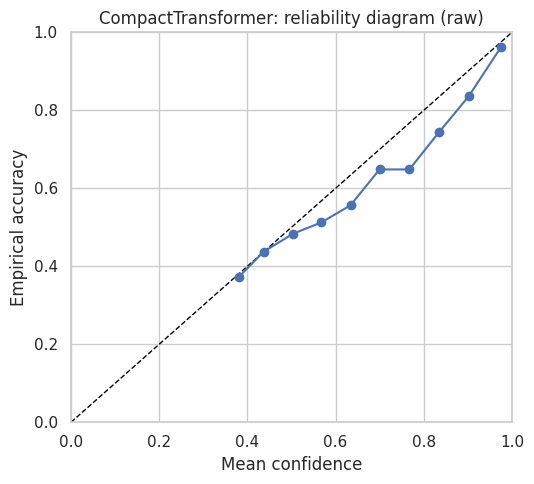

Reliability diagram: BERT (raw)


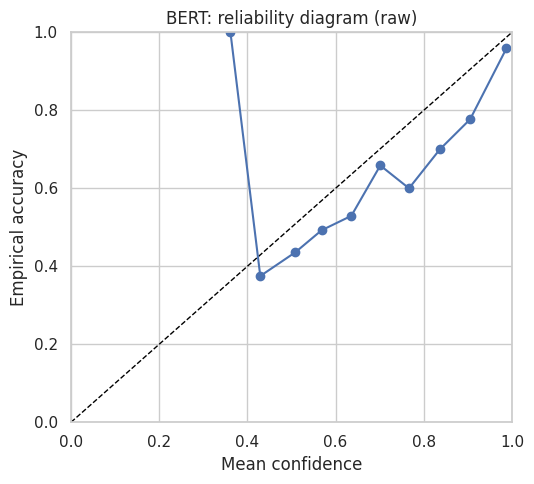

Reliability diagram: CompactTransformer (temperature scaled)


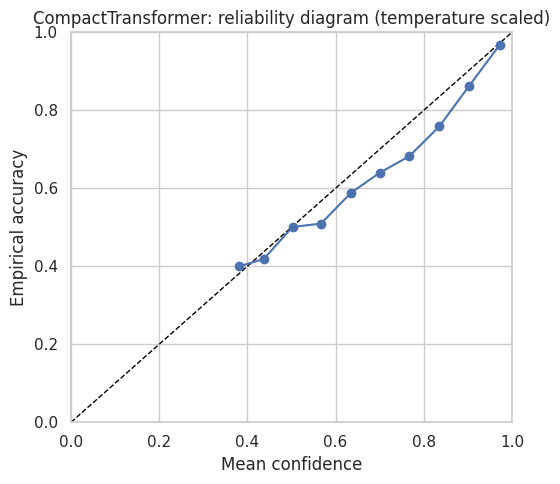

Reliability diagram: BERT (temperature scaled)


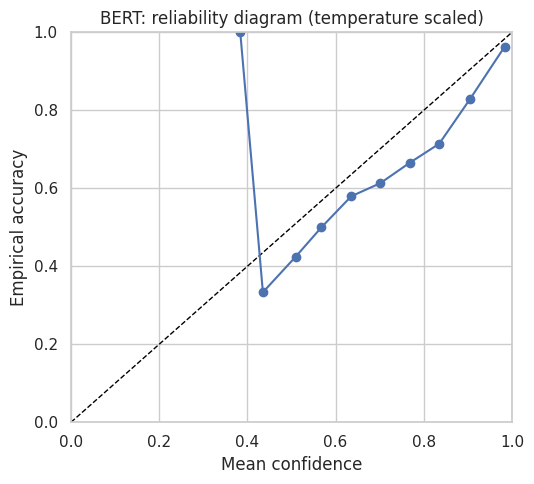

In [35]:

print("Reliability diagram: CompactTransformer (raw)")
plot_reliability_diagram(compact_cal_raw["reliability_df"], "CompactTransformer: reliability diagram (raw)")

print("Reliability diagram: BERT (raw)")
plot_reliability_diagram(bert_cal_raw["reliability_df"], "BERT: reliability diagram (raw)")

if CFG.run_temperature_scaling:
    print("Reliability diagram: CompactTransformer (temperature scaled)")
    plot_reliability_diagram(compact_cal_ts["reliability_df"], "CompactTransformer: reliability diagram (temperature scaled)")

    print("Reliability diagram: BERT (temperature scaled)")
    plot_reliability_diagram(bert_cal_ts["reliability_df"], "BERT: reliability diagram (temperature scaled)")


## Контролируемые ablation-эксперименты для собственной модели

Здесь сравниваются варианты компактной модели по трём основным факторам:

- способ pooling;
- тип positional encoding;
- глубина сети.

Ablation по умолчанию запускается на отдельной фиксированной стратифицированной подвыборке и при меньшем числе эпох. Это не “ослабление ради удобства”, а разумный компромисс между исследовательской полезностью и тем фактом, что Kaggle GPU не обязан участвовать в человеческом культе страдания.


In [36]:
ablation_ds = DatasetDict(
    train=stratified_subsample(clean_ds["train"], CFG.ablation_train_size, seed=CFG.seed),
    validation=stratified_subsample(clean_ds["validation"], CFG.ablation_val_size, seed=CFG.seed),
    test=stratified_subsample(clean_ds["test"], CFG.ablation_test_size, seed=CFG.seed),
)

ablation_tok = DatasetDict()
for split in ablation_ds.keys():
    ablation_tok[split] = ablation_ds[split].map(tokenize_batch, batched=True, remove_columns=["premise", "hypothesis"])

ablation_tok = ablation_tok.rename_column("label", "labels")
ablation_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "token_type_ids", "labels"])

ablation_train_loader = DataLoader(
    ablation_tok["train"],
    batch_size=CFG.batch_size,
    shuffle=True,
    num_workers=CFG.num_workers,
    collate_fn=collator,
    pin_memory=torch.cuda.is_available(),
)
ablation_val_loader = DataLoader(
    ablation_tok["validation"],
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=CFG.num_workers,
    collate_fn=collator,
    pin_memory=torch.cuda.is_available(),
)
ablation_test_loader = DataLoader(
    ablation_tok["test"],
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=CFG.num_workers,
    collate_fn=collator,
    pin_memory=torch.cuda.is_available(),
)

ablation_settings = [
    {"name": "base_cls_learnable_l4", "pooling": "cls", "pos_encoding": "learnable", "num_layers": 4, "d_model": 256, "num_heads": 4, "d_ff": 512},
    {"name": "pool_mean", "pooling": "mean", "pos_encoding": "learnable", "num_layers": 4, "d_model": 256, "num_heads": 4, "d_ff": 512},
    {"name": "pool_max", "pooling": "max", "pos_encoding": "learnable", "num_layers": 4, "d_model": 256, "num_heads": 4, "d_ff": 512},
    {"name": "pos_sinusoidal", "pooling": "cls", "pos_encoding": "sinusoidal", "num_layers": 4, "d_model": 256, "num_heads": 4, "d_ff": 512},
    {"name": "depth_l2", "pooling": "cls", "pos_encoding": "learnable", "num_layers": 2, "d_model": 256, "num_heads": 4, "d_ff": 512},
    {"name": "depth_l6", "pooling": "cls", "pos_encoding": "learnable", "num_layers": 6, "d_model": 256, "num_heads": 4, "d_ff": 512},
]


Map:   0%|          | 0/60000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

In [37]:
ablation_rows = []

for cfg_item in ablation_settings:
    print("=" * 80)
    print("ABLATION:", cfg_item["name"])

    model, local_cfg = build_compact_model(
        pooling=cfg_item["pooling"],
        pos_encoding=cfg_item["pos_encoding"],
        num_layers=cfg_item["num_layers"],
        d_model=cfg_item["d_model"],
        num_heads=cfg_item["num_heads"],
        d_ff=cfg_item["d_ff"],
    )

    model, hist, train_time, ckpt, best_epoch = train_model(
        model,
        ablation_train_loader,
        ablation_val_loader,
        model_name=f"ablation_{cfg_item['name']}",
        model_type="compact",
        epochs=CFG.ablation_epochs,
        lr=CFG.lr_custom,
        weight_decay=CFG.weight_decay,
        warmup_ratio=CFG.warmup_ratio,
        early_stopping_patience=1,
    )

    loss_fn = nn.CrossEntropyLoss()
    val_metrics, _, _, _, _, _ = evaluate_model(model, ablation_val_loader, model_type="compact", loss_fn=loss_fn)
    test_metrics, _, _, _, _, _ = evaluate_model(model, ablation_test_loader, model_type="compact", loss_fn=loss_fn)

    row = {
        "variant": cfg_item["name"],
        "pooling": cfg_item["pooling"],
        "pos_encoding": cfg_item["pos_encoding"],
        "num_layers": cfg_item["num_layers"],
        "d_model": cfg_item["d_model"],
        "num_heads": cfg_item["num_heads"],
        "d_ff": cfg_item["d_ff"],
        "best_epoch": best_epoch,
        "params_millions": round(count_trainable_params(model) / 1_000_000, 3),
        "train_time_min": round(train_time / 60, 2),
        "val_accuracy": round(val_metrics["accuracy"], 4),
        "val_macro_f1": round(val_metrics["macro_f1"], 4),
        "val_ece": round(val_metrics["ece"], 4),
        "test_accuracy": round(test_metrics["accuracy"], 4),
        "test_macro_f1": round(test_metrics["macro_f1"], 4),
        "test_ece": round(test_metrics["ece"], 4),
        "checkpoint": ckpt,
    }
    ablation_rows.append(row)

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

ablation_df = pd.DataFrame(ablation_rows).sort_values("test_macro_f1", ascending=False)
ablation_df.to_csv(OUTPUT_DIR / "ablation_results.csv", index=False)
ablation_df


ABLATION: base_cls_learnable_l4


/tmp/ipykernel_26/4225700641.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)
/tmp/ipykernel_26/4225700641.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


[ablation_base_cls_learnable_l4] epoch=01 train_loss=1.0270 val_loss=0.9617 val_acc=0.5216 val_macro_f1=0.5147 val_ece=0.0341 time=40.3s


/tmp/ipykernel_26/4225700641.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


[ablation_base_cls_learnable_l4] epoch=02 train_loss=0.9447 val_loss=0.9132 val_acc=0.5598 val_macro_f1=0.5591 val_ece=0.0192 time=40.8s


...

/tmp/ipykernel_26/4225700641.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


[ablation_depth_l6] epoch=03 train_loss=0.8841 val_loss=0.8785 val_acc=0.5974 val_macro_f1=0.5969 val_ece=0.0229 time=52.4s


/tmp/ipykernel_26/4225700641.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


[ablation_depth_l6] epoch=04 train_loss=0.8523 val_loss=0.8710 val_acc=0.6080 val_macro_f1=0.6071 val_ece=0.0387 time=52.3s


,variant,pooling,pos_encoding,num_layers,d_model,num_heads,d_ff,best_epoch,params_millions,train_time_min,val_accuracy,val_macro_f1,val_ece,test_accuracy,test_macro_f1,test_ece,checkpoint
3,pos_sinusoidal,cls,sinusoidal,4,256,4,512,4,9.990,2.62,0.6100,0.6088,0.0438,0.6130,0.6117,0.0497,outputs_nli/checkpoints/ablation_pos_sinusoidal_seed42.pt
5,depth_l6,cls,learnable,6,256,4,512,4,11.060,3.48,0.6080,0.6071,0.0387,0.6066,0.6052,0.0398,outputs_nli/checkpoints/ablation_depth_l6_seed42.pt
1,pool_mean,mean,learnable,4,256,4,512,4,10.006,2.66,0.5982,0.5970,0.0502,0.6010,0.5996,0.0522,outputs_nli/checkpoints/ablation_pool_mean_seed42.pt
2,pool_max,max,learnable,4,256,4,512,4,10.006,2.66,0.5896,0.5886,0.0458,0.5892,0.5875,0.0467,outputs_nli/checkpoints/ablation_pool_max_seed42.pt
0,base_cls_learnable_l4,cls,learnable,4,256,4,512,4,10.006,2.68,0.5848,0.5839,0.0355,0.5798,0.5785,0.0439,outputs_nli/checkpoints/ablation_base_cls_learnable_l4_seed42.pt
4,depth_l2,cls,learnable,2,256,4,512,4,8.952,1.90,0.5708,0.5686,0.0264,0.5782,0.5747,0.0383,outputs_nli/checkpoints/ablation_depth_l2_seed42.pt


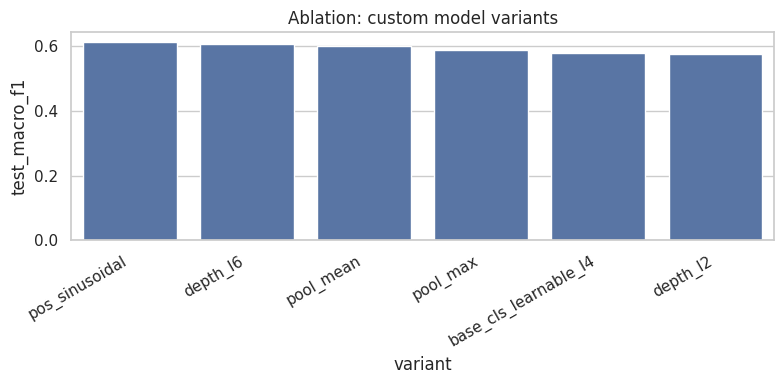

In [38]:
plt.figure(figsize=(8, 4))
sns.barplot(data=ablation_df, x="variant", y="test_macro_f1")
plt.xticks(rotation=30, ha="right")
plt.title("Ablation: custom model variants")
plt.tight_layout()
plt.show()


In [39]:
def build_prediction_frame(ds: Dataset, y_true, y_pred, probs, model_name: str):
    df = ds.to_pandas()[["premise", "hypothesis"]].copy().reset_index(drop=True)
    df["example_id"] = np.arange(len(df))
    df["true_label_id"] = y_true
    df["pred_label_id"] = y_pred
    df["true_label"] = pd.Series(y_true).map(label_id2name)
    df["pred_label"] = pd.Series(y_pred).map(label_id2name)
    df["is_correct"] = df["true_label_id"] == df["pred_label_id"]
    df["confidence"] = probs.max(axis=1)
    df["model"] = model_name
    for i in range(3):
        df[f"prob_{label_id2name[i]}"] = probs[:, i]
    return df

compact_pred_df = build_prediction_frame(exp_ds["test"], compact_y_true, compact_y_pred, compact_probs, "CompactTransformer")
bert_pred_df = build_prediction_frame(exp_ds["test"], bert_y_true, bert_y_pred, bert_probs, "BERT")

if CFG.run_temperature_scaling and compact_probs_ts is not None:
    compact_pred_df["confidence_ts"] = compact_probs_ts.max(axis=1)
    compact_pred_df["pred_label_id_ts"] = compact_probs_ts.argmax(axis=1)
    compact_pred_df["pred_label_ts"] = pd.Series(compact_probs_ts.argmax(axis=1)).map(label_id2name)
    compact_pred_df["is_correct_ts"] = compact_pred_df["pred_label_id_ts"] == compact_pred_df["true_label_id"]

    bert_pred_df["confidence_ts"] = bert_probs_ts.max(axis=1)
    bert_pred_df["pred_label_id_ts"] = bert_probs_ts.argmax(axis=1)
    bert_pred_df["pred_label_ts"] = pd.Series(bert_probs_ts.argmax(axis=1)).map(label_id2name)
    bert_pred_df["is_correct_ts"] = bert_pred_df["pred_label_id_ts"] == bert_pred_df["true_label_id"]

if CFG.save_prediction_frames:
    compact_pred_df.to_csv(OUTPUT_DIR / "compact_predictions.csv", index=False)
    bert_pred_df.to_csv(OUTPUT_DIR / "bert_predictions.csv", index=False)

compact_pred_df.head()


,premise,hypothesis,example_id,true_label_id,pred_label_id,true_label,pred_label,is_correct,confidence,model,prob_entailment,prob_neutral,prob_contradiction,confidence_ts,pred_label_id_ts,pred_label_ts,is_correct_ts
0,This church choir sings to the masses as they sing joyous songs from the book at a church.,The church has cracks in the ceiling.,0,1,2,neutral,contradiction,False,0.883494,CompactTransformer,0.038764,0.077742,0.883494,0.865151,2,contradiction,False
1,This church choir sings to the masses as they sing joyous songs from the book at a church.,The church is filled with song.,1,0,0,entailment,entailment,True,0.869298,CompactTransformer,0.869298,0.090620,0.040082,0.850301,0,entailment,True
2,This church choir sings to the masses as they sing joyous songs from the book at a church.,A choir singing at a baseball game.,2,2,2,contradiction,contradiction,True,0.517415,CompactTransformer,0.096372,0.386212,0.517415,0.508334,2,contradiction,True
3,"A woman with a green headscarf, blue shirt and a very big grin.",The woman is young.,3,1,1,neutral,neutral,True,0.849647,CompactTransformer,0.074579,0.849647,0.075773,0.829166,1,neutral,True
4,"A woman with a green headscarf, blue shirt and a very big grin.",The woman is very happy.,4,0,1,entailment,neutral,False,0.545243,CompactTransformer,0.414115,0.545243,0.040642,0.537505,1,neutral,False


In [40]:
compact_errors = compact_pred_df[~compact_pred_df["is_correct"]].sort_values("confidence", ascending=False)
bert_errors = bert_pred_df[~bert_pred_df["is_correct"]].sort_values("confidence", ascending=False)

print("Самые уверенные ошибки CompactTransformer")
display(compact_errors.head(10))

print("Самые уверенные ошибки BERT")
display(bert_errors.head(10))


Самые уверенные ошибки CompactTransformer


,premise,hypothesis,example_id,true_label_id,pred_label_id,true_label,pred_label,is_correct,confidence,model,prob_entailment,prob_neutral,prob_contradiction,confidence_ts,pred_label_id_ts,pred_label_ts,is_correct_ts
7937,An accordion player with a bright colored shirt sitting outside in a chair with a young man in a blue t-shirt passing by.,A young man is walking.,7937,0,2,entailment,contradiction,False,0.996950,CompactTransformer,0.000756,0.002294,0.996950,0.995462,2,contradiction,False
9745,Cheerleaders in blue performing on a football field underneath a yellow football goal post.,A group of girls shake pom poms.,9745,1,2,neutral,contradiction,False,0.996739,CompactTransformer,0.000332,0.002929,0.996739,0.995237,2,contradiction,False
374,A man in an apron smiles as he pokes a frying donut with a little metal stick.,The man is in the kitchen of a restaurant.,374,1,2,neutral,contradiction,False,0.995960,CompactTransformer,0.000607,0.003434,0.995960,0.994145,2,contradiction,False
2313,"Two boys with blond-hair, wearing striped shirts on a bed.",Two children sleeping in a bedroom.,2313,1,2,neutral,contradiction,False,0.995643,CompactTransformer,0.000474,0.003883,0.995643,0.993748,2,contradiction,False
9251,A teenage girl in a crowd of people looking up at something.,no one saw the rainbow in the sky,9251,1,2,neutral,contradiction,False,0.995416,CompactTransformer,0.001724,0.002860,0.995416,0.993317,2,contradiction,False
558,Boys with their backs against an incoming wave.,A group of people sit on the beach.,558,1,2,neutral,contradiction,False,0.994855,CompactTransformer,0.001534,0.003611,0.994855,0.992578,2,contradiction,False
5017,Three people posing for a camera,Three woman are shopping at the mall.,5017,1,2,neutral,contradiction,False,0.993795,CompactTransformer,0.000198,0.006007,0.993795,0.991407,2,contradiction,False
6309,A child bowling at the bowling alley.,A professional bowling team wins the championship.,6309,2,1,contradiction,neutral,False,0.992687,CompactTransformer,0.002130,0.992687,0.005183,0.989692,1,neutral,False
7353,A group of people and a dog sitting on the steps.,A group of dogs are waiting for their master.,7353,2,1,contradiction,neutral,False,0.992666,CompactTransformer,0.002176,0.992666,0.005158,0.989662,1,neutral,False
5170,There is a man poking a long stick up towards the ceiling.,The man has no arms.,5170,1,2,neutral,contradiction,False,0.992243,CompactTransformer,0.003839,0.003919,0.992243,0.989052,2,contradiction,False


Самые уверенные ошибки BERT


,premise,hypothesis,example_id,true_label_id,pred_label_id,true_label,pred_label,is_correct,confidence,model,prob_entailment,prob_neutral,prob_contradiction,confidence_ts,pred_label_id_ts,pred_label_ts,is_correct_ts
7368,Twenty five people are marching.,A man plays the trombone on the sidewalk.,7368,1,2,neutral,contradiction,False,0.999358,BERT,0.000096,0.000546,0.999358,0.998489,2,contradiction,False
2826,A woman in a striped shirt holds an infant.,A person is watching TV.,2826,1,2,neutral,contradiction,False,0.999346,BERT,0.000096,0.000557,0.999346,0.998466,2,contradiction,False
7927,"Rider in ceremonial garb rides white Arabian horse, also wearing ceremonial blankets and tassels.",Pets galloping down the street.,7927,1,2,neutral,contradiction,False,0.999166,BERT,0.000144,0.000691,0.999166,0.998086,2,contradiction,False
8314,Two men are making hand gestures and posing for a picture.,The men are standing in total darkness.,8314,1,2,neutral,contradiction,False,0.999056,BERT,0.000164,0.000780,0.999056,0.997863,2,contradiction,False
5164,A fireman with a neon helmet and a pickaxe inspects some debris with a flashlight.,A fireman with an axe stands in a burning house.,5164,1,2,neutral,contradiction,False,0.999039,BERT,0.000083,0.000878,0.999039,0.997867,2,contradiction,False
2651,A large crowd is gathered outside and one woman is yelling.,A group of protestors engages with a woman inside an auditorium.,2651,1,2,neutral,contradiction,False,0.998787,BERT,0.000115,0.001098,0.998787,0.997372,2,contradiction,False
5170,There is a man poking a long stick up towards the ceiling.,The man has no arms.,5170,1,2,neutral,contradiction,False,0.998786,BERT,0.000224,0.000990,0.998786,0.997324,2,contradiction,False
2186,"Two skateboarders, one wearing a black t-shirt and the other wearing a white t-shirt, race each other.",Two snowboarders race.,2186,0,2,entailment,contradiction,False,0.998722,BERT,0.000354,0.000925,0.998722,0.997166,2,contradiction,False
9251,A teenage girl in a crowd of people looking up at something.,no one saw the rainbow in the sky,9251,1,2,neutral,contradiction,False,0.998599,BERT,0.000190,0.001211,0.998599,0.996985,2,contradiction,False
5017,Three people posing for a camera,Three woman are shopping at the mall.,5017,1,2,neutral,contradiction,False,0.998574,BERT,0.000124,0.001302,0.998574,0.996971,2,contradiction,False


In [41]:
compact_report = classification_report(
    compact_y_true,
    compact_y_pred,
    labels=[0, 1, 2],
    target_names=[label_id2name[i] for i in [0, 1, 2]],
    output_dict=True,
    zero_division=0,
)
bert_report = classification_report(
    bert_y_true,
    bert_y_pred,
    labels=[0, 1, 2],
    target_names=[label_id2name[i] for i in [0, 1, 2]],
    output_dict=True,
    zero_division=0,
)

print("Classification report: CompactTransformer")
display(pd.DataFrame(compact_report).T)

print("Classification report: BERT")
display(pd.DataFrame(bert_report).T)


Classification report: CompactTransformer


,precision,recall,f1-score,support
entailment,0.817070,0.852732,0.834520,3368.000000
neutral,0.739239,0.736253,0.737743,3219.000000
contradiction,0.820819,0.786840,0.803470,3237.000000
accuracy,0.792854,0.792854,0.792854,0.792854
macro avg,0.792376,0.791942,0.791911,9824.000000
weighted avg,0.792802,0.792854,0.792578,9824.000000


Classification report: BERT


,precision,recall,f1-score,support
entailment,0.918507,0.913599,0.916046,3368.000000
neutral,0.873046,0.867350,0.870189,3219.000000
contradiction,0.929182,0.940377,0.934746,3237.000000
accuracy,0.907268,0.907268,0.907268,0.907268
macro avg,0.906912,0.907109,0.906994,9824.000000
weighted avg,0.907128,0.907268,0.907182,9824.000000


In [42]:
disagreement_df = exp_ds["test"].to_pandas()[["premise", "hypothesis"]].copy().reset_index(drop=True)
disagreement_df["true_label"] = pd.Series(compact_y_true).map(label_id2name)
disagreement_df["compact_pred"] = pd.Series(compact_y_pred).map(label_id2name)
disagreement_df["bert_pred"] = pd.Series(bert_y_pred).map(label_id2name)
disagreement_df["compact_ok"] = compact_y_true == compact_y_pred
disagreement_df["bert_ok"] = bert_y_true == bert_y_pred
disagreement_df["compact_conf"] = compact_probs.max(axis=1)
disagreement_df["bert_conf"] = bert_probs.max(axis=1)

compact_only_good = disagreement_df[(disagreement_df["compact_ok"]) & (~disagreement_df["bert_ok"])].sort_values("compact_conf", ascending=False)
bert_only_good = disagreement_df[(~disagreement_df["compact_ok"]) & (disagreement_df["bert_ok"])].sort_values("bert_conf", ascending=False)

print("Примеры, где CompactTransformer прав, а BERT ошибся")
display(compact_only_good.head(10))

print("Примеры, где BERT прав, а CompactTransformer ошибся")
display(bert_only_good.head(10))


Примеры, где CompactTransformer прав, а BERT ошибся


,premise,hypothesis,true_label,compact_pred,bert_pred,compact_ok,bert_ok,compact_conf,bert_conf
7198,Man with blue and yellow shirt rides bike.,a bike rides a man for its first time,neutral,neutral,contradiction,True,False,0.992624,0.798496
1915,A child buried in the sand.,The child is dead.,contradiction,contradiction,entailment,True,False,0.985572,0.969411
3061,A man wearing a stocking hat and has a beard is looking at the camera with two women sitting on the couch next to him.,there is a dog in the foreground,contradiction,contradiction,neutral,True,False,0.984120,0.640381
9123,A young woman is wearing a paper crown at an outdoor event.,the woman is at a ski lodge,contradiction,contradiction,neutral,True,False,0.980593,0.768122
9142,The dogs are playing on the bed.,Dogs fighting each other for the chance to sleep on the bed.,neutral,neutral,contradiction,True,False,0.980480,0.663647
1544,Man sitting on bench with a suitcase in front of PADDINGTON sign.,A man sitting with a sign,entailment,entailment,neutral,True,False,0.978439,0.543578
9164,A man playing the guitar while smoking a cigarette.,The man is also playing the drums,contradiction,contradiction,neutral,True,False,0.975441,0.808511
9399,A man painting a sign onto his food cart.,Everyone is in a restaurant.,contradiction,contradiction,neutral,True,False,0.974304,0.922229
5617,The man is wearing an orange and black polo shirt and is kneeling with his lunch box in one hand while holding a banana in his other hand.,A man is eating lunch.,entailment,entailment,neutral,True,False,0.973868,0.546842
2701,A man in a tank top fixing himself a hotdog.,two girls were ther,contradiction,contradiction,entailment,True,False,0.970988,0.984141


Примеры, где BERT прав, а CompactTransformer ошибся


,premise,hypothesis,true_label,compact_pred,bert_pred,compact_ok,bert_ok,compact_conf,bert_conf
4231,A man in tribal dress is walking down the street while spectators are standing behind red and white barrier tape.,A group of people deepsea fishing,contradiction,neutral,contradiction,False,True,0.548558,0.999485
3786,A skier goes down a hill with a mountain as a backdrop.,A surfer riding a wave.,contradiction,entailment,contradiction,False,True,0.475754,0.999477
4213,group of people sweeping the floor and cleaning,A group of people are wind surfing over the dunes.,contradiction,neutral,contradiction,False,True,0.697265,0.999466
6943,"Two older men in business attire are walking in a city, text graffiti is visible on the sidewalk.",They propel themselves down the street with rockets,contradiction,neutral,contradiction,False,True,0.499442,0.999445
3015,A local street in an Arabic country where there is a market selling Coca-Cola.,A snowy mountain in the Rockies.,contradiction,neutral,contradiction,False,True,0.388992,0.999424
4730,A man wearing black pants and a helmet is riding a brown horse.,A man is riding a mammoth.,contradiction,neutral,contradiction,False,True,0.526338,0.999413
4748,A woman wearing white and black carries a serving tray.,A woman wearing white and black grips a steering wheel with both hands as she evades the police.,contradiction,neutral,contradiction,False,True,0.854684,0.999413
7139,The tennis player spikes the tennis ball on the boundary line.,A boxer is kayaking.,contradiction,entailment,contradiction,False,True,0.653275,0.999403
7670,a group of skiers jumping down slopes with the sun directly cast in backgroud,A man and a woman ride their bikes down a hill.,contradiction,neutral,contradiction,False,True,0.727273,0.999395
2069,The man in the brown shirt is holding the hand of the long-haired child in front of a painting.,A dad and his kid is fishing in the middle of the Pacific ocean.,contradiction,neutral,contradiction,False,True,0.601538,0.999390



## Diagnostic slices: overlap, negation, length buckets и neutral-only анализ

Высокая усреднённая метрика может скрывать очень земные проблемы.  
Поэтому ниже строятся простые, но полезные срезы ошибок по признакам, которые особенно часто связаны с shortcut behavior в NLI:

- **lexical overlap**
- **наличие отрицания**
- **длина premise / hypothesis**
- отдельный анализ только для **neutral**

Это не заменяет полноценный OOD benchmark, но даёт уже намного более содержательную картину, чем одна строка с macro-F1.


In [43]:

WORD_RE = re.compile(r"[a-z]+(?:'[a-z]+)?")
NEGATION_WORDS = {"not", "no", "never", "none", "nobody", "nothing", "neither", "nor", "without", "cannot", "can't", "won't", "n't"}

def tokenize_for_diagnostics(text: str) -> List[str]:
    return WORD_RE.findall(str(text).lower())

def build_diagnostic_feature_frame(ds: Dataset) -> pd.DataFrame:
    df = ds.to_pandas()[["premise", "hypothesis", "label"]].copy().reset_index(drop=True)

    premise_tokens = df["premise"].map(tokenize_for_diagnostics)
    hypothesis_tokens = df["hypothesis"].map(tokenize_for_diagnostics)

    premise_sets = premise_tokens.map(set)
    hypothesis_sets = hypothesis_tokens.map(set)

    df["premise_words"] = premise_tokens.map(len)
    df["hypothesis_words"] = hypothesis_tokens.map(len)
    df["pair_words_sum"] = df["premise_words"] + df["hypothesis_words"]
    df["length_gap_abs"] = (df["premise_words"] - df["hypothesis_words"]).abs()

    df["overlap_hypothesis_ratio"] = [
        len(p & h) / max(len(h), 1)
        for p, h in zip(premise_sets, hypothesis_sets)
    ]
    df["jaccard_overlap"] = [
        len(p & h) / max(len(p | h), 1)
        for p, h in zip(premise_sets, hypothesis_sets)
    ]
    df["has_negation"] = [
        bool((set(p) | set(h)) & NEGATION_WORDS)
        for p, h in zip(premise_tokens, hypothesis_tokens)
    ]
    df["premise_has_negation"] = [bool(set(p) & NEGATION_WORDS) for p in premise_tokens]
    df["hypothesis_has_negation"] = [bool(set(h) & NEGATION_WORDS) for h in hypothesis_tokens]

    df["overlap_bin"] = pd.cut(
        df["overlap_hypothesis_ratio"],
        bins=[-0.01, 0.2, 0.5, 1.0],
        labels=["low", "medium", "high"],
    )

    df["pair_len_bin"] = pd.qcut(
        df["pair_words_sum"],
        q=3,
        labels=["short", "medium", "long"],
        duplicates="drop",
    )

    df["true_label"] = df["label"].map(label_id2name)
    return df

def attach_diagnostics(pred_df: pd.DataFrame, feature_df: pd.DataFrame) -> pd.DataFrame:
    cols = [
        "overlap_hypothesis_ratio",
        "jaccard_overlap",
        "has_negation",
        "premise_has_negation",
        "hypothesis_has_negation",
        "premise_words",
        "hypothesis_words",
        "pair_words_sum",
        "length_gap_abs",
        "overlap_bin",
        "pair_len_bin",
    ]
    out = pred_df.merge(feature_df.reset_index().rename(columns={"index": "example_id"})[["example_id"] + cols], on="example_id", how="left")
    return out

def build_slice_metric_table(pred_df: pd.DataFrame, group_col: str, model_name: Optional[str] = None) -> pd.DataFrame:
    rows = []
    for group_value, part in pred_df.groupby(group_col, dropna=False):
        if len(part) == 0:
            continue
        metrics, _ = compute_metrics(part["true_label_id"], part["pred_label_id"])
        rows.append(
            {
                "model": model_name or part["model"].iloc[0],
                "slice": group_col,
                "group": str(group_value),
                "n": len(part),
                "accuracy": round(metrics["accuracy"], 4),
                "macro_f1": round(metrics["macro_f1"], 4),
                "weighted_f1": round(metrics["weighted_f1"], 4),
                "mean_confidence": round(float(part["confidence"].mean()), 4),
            }
        )
    return pd.DataFrame(rows)

diag_base_df = build_diagnostic_feature_frame(exp_ds["test"])
compact_diag_df = attach_diagnostics(compact_pred_df, diag_base_df)
bert_diag_df = attach_diagnostics(bert_pred_df, diag_base_df)


In [44]:

slice_tables = []

for group_col in ["overlap_bin", "has_negation", "pair_len_bin"]:
    slice_tables.append(build_slice_metric_table(compact_diag_df, group_col, model_name="CompactTransformer"))
    slice_tables.append(build_slice_metric_table(bert_diag_df, group_col, model_name="BERT"))

slice_metrics_df = pd.concat(slice_tables, ignore_index=True)
slice_metrics_df.to_csv(OUTPUT_DIR / "slice_metrics.csv", index=False)

display(slice_metrics_df.sort_values(["slice", "model", "group"]).reset_index(drop=True))


/tmp/ipykernel_26/3347192373.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_value, part in pred_df.groupby(group_col, dropna=False):
/tmp/ipykernel_26/3347192373.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_value, part in pred_df.groupby(group_col, dropna=False):
/tmp/ipykernel_26/3347192373.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_value, part in pred_df.groupby(gro

,model,slice,group,n,accuracy,macro_f1,weighted_f1,mean_confidence
0,BERT,has_negation,False,9573,0.9067,0.9067,0.9066,0.9509
1,BERT,has_negation,True,251,0.9283,0.9040,0.9273,0.9714
2,CompactTransformer,has_negation,False,9573,0.7924,0.7915,0.7921,0.8351
3,CompactTransformer,has_negation,True,251,0.8088,0.7458,0.8046,0.8513
4,BERT,overlap_bin,high,3469,0.9187,0.9089,0.9188,0.9513
5,BERT,overlap_bin,low,1566,0.8934,0.8822,0.8931,0.9548
6,BERT,overlap_bin,medium,4789,0.9035,0.9011,0.9034,0.9504
7,CompactTransformer,overlap_bin,high,3469,0.8170,0.7804,0.8152,0.8523
8,CompactTransformer,overlap_bin,low,1566,0.7637,0.7498,0.7636,0.8210
9,CompactTransformer,overlap_bin,medium,4789,0.7849,0.7837,0.7852,0.8281


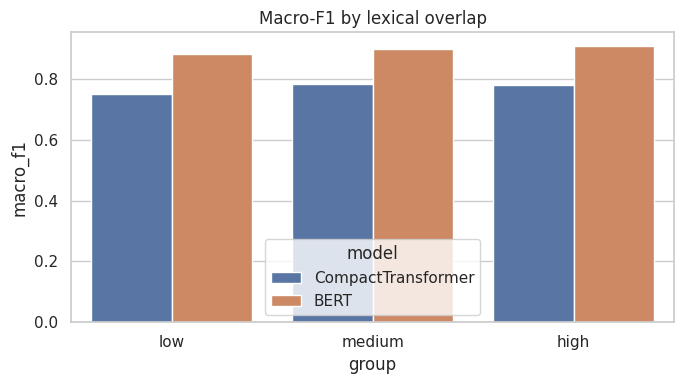

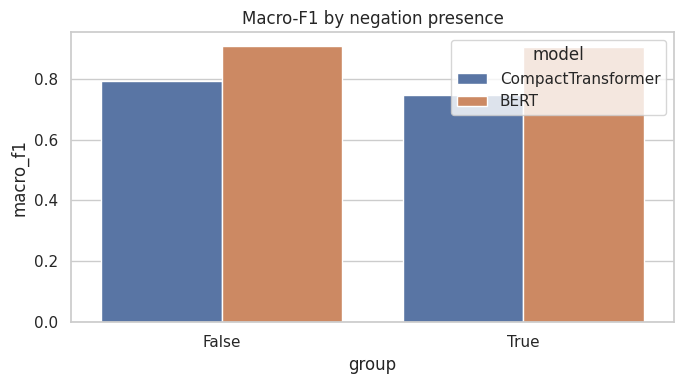

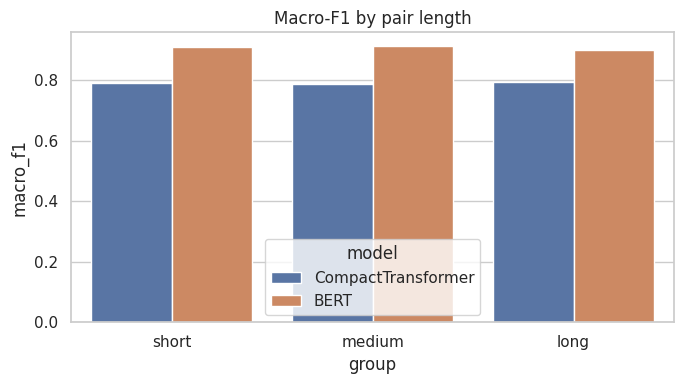

Neutral-only slices


/tmp/ipykernel_26/3347192373.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_value, part in pred_df.groupby(group_col, dropna=False):
/tmp/ipykernel_26/3347192373.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_value, part in pred_df.groupby(group_col, dropna=False):


,model,slice,group,n,accuracy,macro_f1,weighted_f1,mean_confidence
0,CompactTransformer,overlap_bin,low,582,0.7062,0.2759,0.8278,0.7784
1,CompactTransformer,overlap_bin,medium,1774,0.7599,0.2878,0.8635,0.7992
2,CompactTransformer,overlap_bin,high,863,0.7080,0.2763,0.8290,0.7911
3,BERT,overlap_bin,low,582,0.8505,0.3064,0.9192,0.9367
4,BERT,overlap_bin,medium,1774,0.8766,0.3114,0.9342,0.9367
5,BERT,overlap_bin,high,863,0.8598,0.3082,0.9246,0.9360


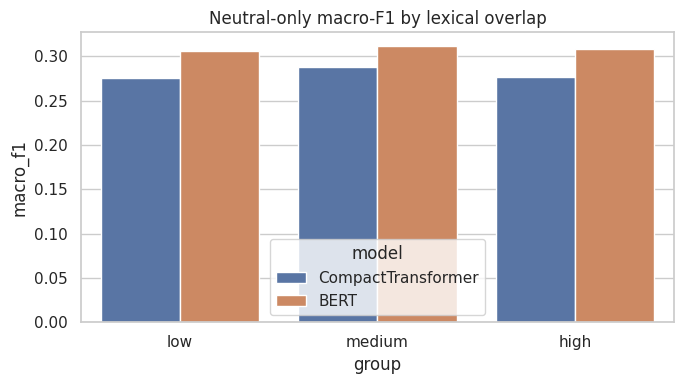

In [45]:

for group_col, title in [
    ("overlap_bin", "Macro-F1 by lexical overlap"),
    ("has_negation", "Macro-F1 by negation presence"),
    ("pair_len_bin", "Macro-F1 by pair length"),
]:
    plt.figure(figsize=(7, 4))
    tmp = slice_metrics_df[slice_metrics_df["slice"] == group_col]
    sns.barplot(data=tmp, x="group", y="macro_f1", hue="model")
    plt.title(title)
    plt.tight_layout()
    plt.show()

neutral_slice_rows = []
for model_name, df_ in [("CompactTransformer", compact_diag_df), ("BERT", bert_diag_df)]:
    part = df_[df_["true_label"] == "neutral"].copy()
    neutral_slice_rows.append(build_slice_metric_table(part, "overlap_bin", model_name=model_name))

neutral_slice_df = pd.concat(neutral_slice_rows, ignore_index=True)
neutral_slice_df.to_csv(OUTPUT_DIR / "neutral_slice_metrics.csv", index=False)

print("Neutral-only slices")
display(neutral_slice_df)

plt.figure(figsize=(7, 4))
sns.barplot(data=neutral_slice_df, x="group", y="macro_f1", hue="model")
plt.title("Neutral-only macro-F1 by lexical overlap")
plt.tight_layout()
plt.show()



## Optional OOD block: HANS-style evaluation

Если `CFG.run_hans_eval = True`, ниже запускается внешний диагностический блок на HANS.  
Он нужен не для того, чтобы устраивать культ внешних benchmark-ов ради одной таблички, а чтобы проверить бинарное различение **entailment vs non-entailment** на датасете, специально построенном против поверхностных эвристик.

In [46]:

def run_hans_binary_eval(compact_model, bert_model):
    try:
        hans_raw = load_dataset("hans")
    except Exception as e:
        print("HANS load failed:", e)
        return None

    split_name = "validation" if "validation" in hans_raw else list(hans_raw.keys())[0]
    hans_ds = hans_raw[split_name]

    required_cols = {"premise", "hypothesis"}
    if not required_cols.issubset(set(hans_ds.column_names)):
        print("Unexpected HANS schema:", hans_ds.column_names)
        return None

    if "label" not in hans_ds.column_names:
        print("HANS label column not found.")
        return None

    def normalize_hans_label(x):
        label = x["label"]
        if isinstance(label, str):
            label = label.lower().strip()
            return {"binary_label": 1 if label == "entailment" else 0}
        return {"binary_label": 1 if int(label) == 0 else 0}

    hans_ds = hans_ds.map(normalize_hans_label)

    def tokenize_hans(batch):
        return tokenizer(
            batch["premise"],
            batch["hypothesis"],
            truncation=True,
            max_length=CFG.max_len,
            return_attention_mask=True,
            return_token_type_ids=True,
        )

    hans_tok = hans_ds.map(tokenize_hans, batched=True)
    keep_cols = [c for c in ["input_ids", "attention_mask", "token_type_ids", "binary_label"] if c in hans_tok.column_names]
    hans_tok = hans_tok.remove_columns([c for c in hans_tok.column_names if c not in keep_cols])
    hans_tok = hans_tok.rename_column("binary_label", "labels")
    hans_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "token_type_ids", "labels"])

    hans_loader = DataLoader(
        hans_tok,
        batch_size=CFG.batch_size,
        shuffle=False,
        num_workers=CFG.num_workers,
        collate_fn=collator,
        pin_memory=torch.cuda.is_available(),
    )

    rows = []
    for model_name, model, model_type, loss_fn in [
        ("CompactTransformer", compact_model, "compact", nn.CrossEntropyLoss()),
        ("BERT", bert_model, "bert", None),
    ]:
        _, _, y_true, y_pred, probs, _ = evaluate_model(model, hans_loader, model_type=model_type, loss_fn=loss_fn)

        y_true_bin = y_true.astype(int)
        y_pred_bin = (y_pred == 0).astype(int)   # entailment = 1, everything else = 0
        acc = accuracy_score(y_true_bin, y_pred_bin)
        f1 = f1_score(y_true_bin, y_pred_bin, average="binary")
        rows.append({"model": model_name, "hans_binary_accuracy": round(float(acc), 4), "hans_binary_f1": round(float(f1), 4)})

    out = pd.DataFrame(rows)
    out.to_csv(OUTPUT_DIR / "hans_binary_eval.csv", index=False)
    return out

if CFG.run_hans_eval:
    hans_eval_df = run_hans_binary_eval(compact_model, bert_model)
    display(hans_eval_df)
else:
    print("CFG.run_hans_eval == False. HANS block skipped.")


README.md: 0.00B [00:00, ?B/s]

hans.py: 0.00B [00:00, ?B/s]

HANS load failed: Dataset scripts are no longer supported, but found hans.py


None

## Визуализация attention для собственной модели

Блок ниже вытягивает attention map из последнего encoder-блока компактной модели для отдельного примера. Это удобный способ посмотреть, на какие токены модель опирается сильнее.


## Устойчивость результатов по нескольким seed

Optional multi-seed блок.

По умолчанию он выключен, потому что это дорого по времени.  
Если нужно, включи:

- `CFG.multi_seed_enabled = True`
- выбери модели через `CFG.multi_seed_models`, например `("compact",)` или `("compact", "bert")`
- задай seeds в `CFG.multi_seed_values`

Для финального исследовательского прогона разумный минимум - хотя бы **3 seed** для CompactTransformer.


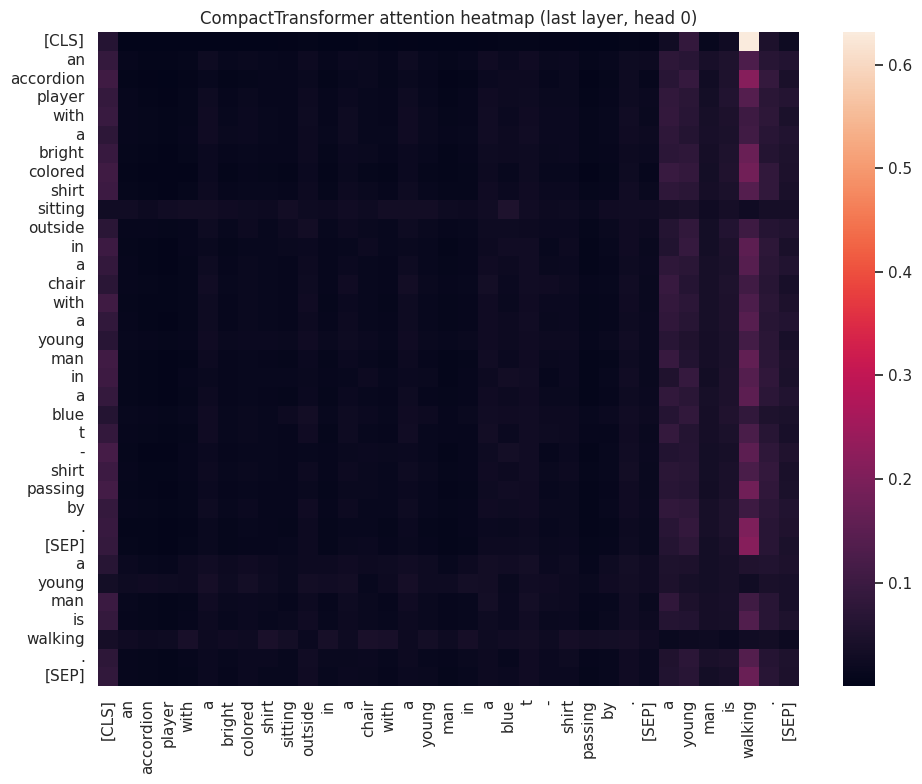

True label: entailment
Pred label: contradiction
Confidence: 0.9969
Premise: An accordion player with a bright colored shirt sitting outside in a chair with a young man in a blue t-shirt passing by.
Hypothesis: A young man is walking.


In [47]:
@torch.no_grad()
def get_compact_attention_map(model, premise: str, hypothesis: str, layer_idx: int = -1, head_idx: int = 0):
    model.eval()
    enc = tokenizer(
        premise,
        hypothesis,
        truncation=True,
        max_length=CFG.max_len,
        return_attention_mask=True,
        return_token_type_ids=True,
        return_tensors="pt",
    )
    enc = {k: v.to(device) for k, v in enc.items()}
    out = model(
        input_ids=enc["input_ids"],
        attention_mask=enc["attention_mask"],
        token_type_ids=enc["token_type_ids"],
        return_attentions=True,
    )
    attn = out["attentions"][layer_idx][0, head_idx].detach().cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0].detach().cpu().tolist())
    valid_len = int(enc["attention_mask"][0].sum().item())
    return tokens[:valid_len], attn[:valid_len, :valid_len]

# Берём не случайный пример, а уверенную ошибку компактной модели: так полезнее для анализа.
attn_example = compact_errors.iloc[0] if len(compact_errors) > 0 else compact_pred_df.iloc[0]

tokens, attn_map = get_compact_attention_map(
    compact_model,
    attn_example["premise"],
    attn_example["hypothesis"],
    layer_idx=-1,
    head_idx=0,
)

plt.figure(figsize=(10, 8))
sns.heatmap(attn_map, xticklabels=tokens, yticklabels=tokens)
plt.xticks(rotation=90)
plt.title("CompactTransformer attention heatmap (last layer, head 0)")
plt.tight_layout()
plt.show()

print("True label:", attn_example["true_label"])
print("Pred label:", attn_example["pred_label"])
print("Confidence:", round(float(attn_example["confidence"]), 4))
print("Premise:", attn_example["premise"])
print("Hypothesis:", attn_example["hypothesis"])


In [48]:
def run_multi_seed_experiment(model_key: str, seed_values: Tuple[int, ...]) -> pd.DataFrame:
    rows = []
    base_state = deepcopy(asdict(CFG))

    for seed in seed_values:
        print("=" * 80)
        print(f"MULTI-SEED RUN | model={model_key} | seed={seed}")

        CFG.seed = seed
        set_seed(seed)

        train_loader, val_loader, test_loader = make_loaders(tokenized_ds, seed)

        if model_key == "compact":
            model, _ = build_compact_model()
            model_type = "compact"
            lr = CFG.lr_custom
            epochs = CFG.epochs_custom
            loss_fn = nn.CrossEntropyLoss()
        elif model_key == "bert":
            model = build_bert_model()
            model_type = "bert"
            lr = CFG.lr_bert
            epochs = CFG.epochs_bert
            loss_fn = None
        else:
            raise ValueError(f"Unknown model_key: {model_key}")

        model, hist, train_time, ckpt, best_epoch = train_model(
            model,
            train_loader,
            val_loader,
            model_name=f"{model_key}_seed_{seed}",
            model_type=model_type,
            epochs=epochs,
            lr=lr,
            weight_decay=CFG.weight_decay,
            warmup_ratio=CFG.warmup_ratio,
            early_stopping_patience=CFG.early_stopping_patience,
        )

        test_metrics, _, _, _, _, _ = evaluate_model(
            model,
            test_loader,
            model_type=model_type,
            loss_fn=loss_fn,
        )

        rows.append(
            {
                "model": model_key,
                "seed": seed,
                "best_epoch": best_epoch,
                "test_accuracy": test_metrics["accuracy"],
                "test_macro_f1": test_metrics["macro_f1"],
                "test_ece": test_metrics["ece"],
                "train_time_min": train_time / 60,
            }
        )

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    CFG.seed = base_state["seed"]
    set_seed(CFG.seed)
    return pd.DataFrame(rows)

if CFG.multi_seed_enabled:
    multi_seed_frames = []
    for model_key in CFG.multi_seed_models:
        multi_seed_frames.append(run_multi_seed_experiment(model_key, CFG.multi_seed_values))

    multi_seed_df = pd.concat(multi_seed_frames, ignore_index=True)
    multi_seed_df.to_csv(OUTPUT_DIR / "multi_seed_results.csv", index=False)
    display(multi_seed_df.round(4))

    summary = (
        multi_seed_df.groupby("model")[["test_accuracy", "test_macro_f1", "test_ece", "train_time_min"]]
        .agg(["mean", "std"])
        .round(4)
    )

    summary_pretty = summary.copy()
    for metric in ["test_accuracy", "test_macro_f1", "test_ece", "train_time_min"]:
        summary_pretty[(metric, "mean±std")] = summary.apply(
            lambda row: f"{row[(metric, 'mean')]:.4f} ± {row[(metric, 'std')]:.4f}",
            axis=1,
        )

    display(summary)
    display(summary_pretty.loc[:, pd.IndexSlice[:, "mean±std"]])
else:
    print("CFG.multi_seed_enabled == False. Multi-seed block skipped.")


MULTI-SEED RUN | model=compact | seed=42


/tmp/ipykernel_26/4225700641.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)
/tmp/ipykernel_26/4225700641.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


[compact_seed_42] epoch=01 train_loss=0.9342 val_loss=0.8287 val_acc=0.6262 val_macro_f1=0.6261 val_ece=0.0403 time=350.5s


/tmp/ipykernel_26/4225700641.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


[compact_seed_42] epoch=02 train_loss=0.7840 val_loss=0.6892 val_acc=0.7111 val_macro_f1=0.7080 val_ece=0.0263 time=349.3s


...

/tmp/ipykernel_26/4225700641.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


[compact_seed_62] epoch=08 train_loss=0.5525 val_loss=0.5392 val_acc=0.7864 val_macro_f1=0.7851 val_ece=0.0437 time=347.3s


,model,seed,best_epoch,test_accuracy,test_macro_f1,test_ece,train_time_min
0,compact,42,8,0.7961,0.7953,0.0400,46.6917
1,compact,52,8,0.7948,0.7938,0.0361,46.8941
2,compact,62,8,0.7862,0.7850,0.0444,46.8714


test_accuracy         test_macro_f1         test_ece          \
                 mean     std          mean     std     mean     std   
model                                                                  
compact        0.7924  0.0054        0.7914  0.0056   0.0402  0.0041   

        train_time_min          
                  mean     std  
model                           
compact         46.819  0.1109

,test_accuracy,test_macro_f1,test_ece,train_time_min
,mean±std,mean±std,mean±std,mean±std
model,,,,
compact,0.7924 ± 0.0054,0.7914 ± 0.0056,0.0402 ± 0.0041,46.8190 ± 0.1109


## Автосохранение артефактов эксперимента


In [49]:
environment_info = {
    "python": sys.version,
    "torch": torch.__version__,
    "transformers": __import__("transformers").__version__,
    "datasets": __import__("datasets").__version__,
    "device": str(device),
}

experiment_artifacts = {
    "train_config": asdict(CFG),
    "compact_config": asdict(compact_cfg),
    "environment_info": environment_info,
    "comparison_table_path": str(OUTPUT_DIR / "model_comparison.csv"),
    "relative_tradeoff_summary_path": str(OUTPUT_DIR / "relative_tradeoff_summary.csv"),
    "calibration_summary_path": str(OUTPUT_DIR / "calibration_summary.csv"),
    "slice_metrics_path": str(OUTPUT_DIR / "slice_metrics.csv"),
    "neutral_slice_metrics_path": str(OUTPUT_DIR / "neutral_slice_metrics.csv"),
    "ablation_table_path": str(OUTPUT_DIR / "ablation_results.csv"),
    "compact_result_path": str(OUTPUT_DIR / "compact_result.json"),
    "bert_result_path": str(OUTPUT_DIR / "bert_result.json"),
    "compact_predictions_path": str(OUTPUT_DIR / "compact_predictions.csv"),
    "bert_predictions_path": str(OUTPUT_DIR / "bert_predictions.csv"),
    "temperature_scaling": temp_scaling_artifacts,
}

if CFG.multi_seed_enabled:
    experiment_artifacts["multi_seed_results_path"] = str(OUTPUT_DIR / "multi_seed_results.csv")

save_json(experiment_artifacts, OUTPUT_DIR / "experiment_artifacts.json")
save_json(asdict(CFG), OUTPUT_DIR / "train_config.json")
save_json(asdict(compact_cfg), OUTPUT_DIR / "compact_config.json")
save_json(environment_info, OUTPUT_DIR / "environment_info.json")

pd.DataFrame(
    [{"artifact": k, "value": v} for k, v in experiment_artifacts.items()]
)


,artifact,value
0,train_config,"{'seed': 42, 'model_name': 'bert-base-uncased', 'max_len': 64, 'batch_size': 32, 'epochs_custom': 8, 'epochs_bert': 3, 'lr_custom': 0.00015, 'lr_bert': 2e-05, 'weight_decay': 0..."
1,compact_config,"{'vocab_size': 30522, 'max_len': 64, 'num_labels': 3, 'pad_token_id': 0, 'type_vocab_size': 2, 'd_model': 256, 'num_heads': 4, 'num_layers': 4, 'd_ff': 512, 'dropout': 0.1, 'po..."
2,environment_info,"{'python': '3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]', 'torch': '2.9.0+cu126', 'transformers': '5.2.0', 'datasets': '4.0.0', 'device': 'cuda'}"
3,comparison_table_path,outputs_nli/model_comparison.csv
4,relative_tradeoff_summary_path,outputs_nli/relative_tradeoff_summary.csv
5,calibration_summary_path,outputs_nli/calibration_summary.csv
6,slice_metrics_path,outputs_nli/slice_metrics.csv
7,neutral_slice_metrics_path,outputs_nli/neutral_slice_metrics.csv
8,ablation_table_path,outputs_nli/ablation_results.csv
9,compact_result_path,outputs_nli/compact_result.json


## Ограничения исследования

1. **Один основной датасет**. Здесь используется SNLI как главный benchmark. Этого достаточно для controlled comparison, но недостаточно для глобальных выводов про все варианты NLI.
2. **Неравенство по предобучению**. BERT приходит с крупномасштабным языковым предобучением, а компактная модель обучается с нуля на целевом датасете. Поэтому сравнение честно показывает trade-off, но не является чистым сравнением “архитектура против архитектуры” в вакууме.
3. **Ресурсный режим Kaggle**. В `kaggle_safe` используются фиксированные стратифицированные подвыборки. Это полезно для воспроизводимости и практического запуска, но может немного менять абсолютные значения метрик.
4. **Диагностические срезы не равны полноценному reasoning benchmark**. Overlap, negation и length slices полезны, но они не исчерпывают все типы логических провалов.
5. **Temperature scaling - post-hoc метод**. Он улучшает calibration quality, но не делает модель “умнее” по содержанию; он меняет только форму confidence estimates.
6. **Ablation считается в ограниченном бюджете**. Поэтому результаты ablation надо трактовать как сравнение направлений и факторов, а не как окончательный ответ на все архитектурные вопросы.
7. **Multi-seed и HANS optional**. Если они не включены, выводы нужно честно называть сильными предварительными, а не окончательно стабилизированными.


In [50]:
def build_conclusion_template(compare_df: pd.DataFrame, ablation_df: pd.DataFrame, calibration_df: pd.DataFrame, neutral_slice_df: pd.DataFrame):
    compact_row = compare_df[compare_df["model"] == "CompactTransformer"].iloc[0]
    bert_row = compare_df[compare_df["model"] == "BERT"].iloc[0]
    best_main = compare_df.sort_values("test_macro_f1", ascending=False).iloc[0]
    best_ablation = ablation_df.sort_values("test_macro_f1", ascending=False).iloc[0]

    macro_gap = bert_row["test_macro_f1"] - compact_row["test_macro_f1"]
    size_ratio = compression_ratio(compact_result["trainable_params"], bert_result["trainable_params"])
    speed_ratio = safe_div(compact_result["items_per_sec"], bert_result["items_per_sec"])

    neutral_summary = neutral_slice_df.pivot(index="group", columns="model", values="macro_f1")
    hardest_neutral_group = None
    if not neutral_summary.empty and "CompactTransformer" in neutral_summary.columns:
        hardest_neutral_group = neutral_summary["CompactTransformer"].sort_values().index[0]

    cal_pivot = calibration_df.pivot(index="model", columns="stage", values="ece")
    compact_cal_text = ""
    bert_cal_text = ""
    if "raw" in cal_pivot.columns:
        compact_cal_text = f"raw ECE={cal_pivot.loc['CompactTransformer', 'raw']:.4f}"
        bert_cal_text = f"raw ECE={cal_pivot.loc['BERT', 'raw']:.4f}"
        ts_cols = [c for c in cal_pivot.columns if str(c).startswith("temperature_scaled")]
        if ts_cols:
            compact_cal_text += f", scaled ECE={cal_pivot.loc['CompactTransformer', ts_cols[0]]:.4f}"
            bert_cal_text += f", scaled ECE={cal_pivot.loc['BERT', ts_cols[0]]:.4f}"

    text = f'''
Черновик содержательных выводов по notebook

1. Лучшее итоговое качество по test macro-F1 показала модель **{best_main["model"]}**.
2. CompactTransformer использует около **{compact_row["params_millions"]:.2f} млн параметров**, тогда как BERT использует около **{bert_row["params_millions"]:.2f} млн**.
   Это даёт коэффициент сжатия примерно **{size_ratio:.2f}x** в пользу компактной модели.
3. Разрыв по test macro-F1 между BERT и CompactTransformer составил примерно **{macro_gap:.4f}**.
   Значит, компактная модель действительно платит качеством за вычислительную экономию, но делает это не бесплатно и не бессмысленно.
4. По скорости инференса CompactTransformer даёт примерно **{speed_ratio:.2f}x** throughput относительно BERT на измеренном микробенчмарке.
5. В ablation-блоке лучшую конфигурацию показал вариант **{best_ablation["variant"]}**.
   Это означает, что внутри собственной архитектуры важен не только сам факт “маленькой модели”, но и конкретный выбор pooling / positional encoding / depth.
6. По калибровке уверенности нужно смотреть не только на accuracy:
   - CompactTransformer: {compact_cal_text}
   - BERT: {bert_cal_text}
   Если temperature scaling улучшает ECE/NLL, это нужно отдельно отметить как полезное post-hoc улучшение без переобучения.
7. В диагностическом анализе отдельного внимания требует класс **neutral**.
   Наиболее трудным neutral-срезом для CompactTransformer оказался: **{hardest_neutral_group if hardest_neutral_group is not None else 'нужно посмотреть по таблице neutral_slice_df'}**.
8. Практический смысл работы состоит не в констатации того, что “BERT лучше”, а в ответе на более важный вопрос:
   **где проходит граница оправданного упрощения encoder-only модели при ограничениях по параметрам, скорости и надёжности confidence estimates**.
9. Корректный финальный вывод должен быть двусоставным:
   - BERT остаётся сильнейшим quality baseline;
   - CompactTransformer может быть practically meaningful вариантом там, где важнее размер, скорость, прозрачность эксперимента и контроль архитектуры.
'''.strip()
    return text

final_conclusion_text = build_conclusion_template(compare_df, ablation_df, calibration_df, neutral_slice_df)
print(final_conclusion_text)

with open(OUTPUT_DIR / "final_conclusion_template.txt", "w", encoding="utf-8") as f:
    f.write(final_conclusion_text)


Черновик содержательных выводов по notebook

1. Лучшее итоговое качество по test macro-F1 показала модель **BERT**.
2. CompactTransformer использует около **10.01 млн параметров**, тогда как BERT использует около **109.48 млн**.
   Это даёт коэффициент сжатия примерно **10.94x** в пользу компактной модели.
3. Разрыв по test macro-F1 между BERT и CompactTransformer составил примерно **0.1151**.
   Значит, компактная модель действительно платит качеством за вычислительную экономию, но делает это не бесплатно и не бессмысленно.
4. По скорости инференса CompactTransformer даёт примерно **18.37x** throughput относительно BERT на измеренном микробенчмарке.
5. В ablation-блоке лучшую конфигурацию показал вариант **pos_sinusoidal**.
   Это означает, что внутри собственной архитектуры важен не только сам факт “маленькой модели”, но и конкретный выбор pooling / positional encoding / depth.
6. По калибровке уверенности нужно смотреть не только на accuracy:
   - CompactTransformer: raw ECE=0.0427,